In [1]:
!pip install kymatio
!pip install captum

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset
from torch.cuda.amp import autocast, GradScaler

from torchvision import transforms, datasets, utils

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from kymatio.torch import Scattering2D


 Paths successfully set:
   Adenocarcinoma: /kaggle/input/lung-cancer-histopathological-images/adenocarcinoma
   Benign: /kaggle/input/lung-cancer-histopathological-images/benign


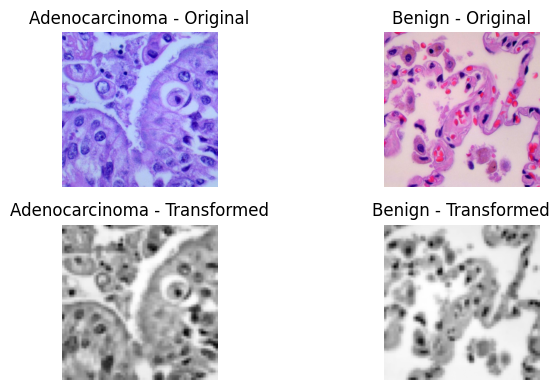

In [4]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
IMG_SIZE= 64

# Define paths for training and testing
kaggle_root = '/kaggle/input/lung-cancer-histopathological-images'
adenocarcinoma_path = os.path.join(kaggle_root, 'adenocarcinoma')
benign_path = os.path.join(kaggle_root, 'benign')

# --- VERIFICATION ---
if os.path.exists(adenocarcinoma_path) and os.path.exists(benign_path):
    print(f" Paths successfully set:")
    print(f"   Adenocarcinoma: {adenocarcinoma_path}")
    print(f"   Benign: {benign_path}")
else:
    print(" Paths not found directly. Searching directory tree...")
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'adenocarcinoma' in dirs:
            adenocarcinoma_path = os.path.join(root, 'adenocarcinoma')
        if 'benign' in dirs:
            benign_path = os.path.join(root, 'benign')
            
    print(f"   Found Adenocarcinoma at: {adenocarcinoma_path}")
    print(f"   Found Benign at: {benign_path}")


transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Show one image from each dataset before and after transformation
def show_sample_images():
    adenocarcinoma_files = os.listdir(adenocarcinoma_path)
    benign_files = os.listdir(benign_path)

    # Load one image from each class without transformation
    adenocarcinoma_img = Image.open(os.path.join(adenocarcinoma_path, adenocarcinoma_files[0]))
    benign_img = Image.open(os.path.join(benign_path, benign_files[0]))

    # Apply transformation
    adenocarcinoma_img_transformed = transform(adenocarcinoma_img)
    benign_img_transformed = transform(benign_img)

    # Plot original images
    plt.figure(figsize=(8,4))
    plt.subplot(2,2,1)
    plt.title("Adenocarcinoma - Original")
    plt.imshow(adenocarcinoma_img)
    plt.axis('off')

    plt.subplot(2,2,2)
    plt.title("Benign - Original")
    plt.imshow(benign_img)
    plt.axis('off')

    # Plot transformed images (show as grayscale)
    plt.subplot(2,2,3)
    plt.title("Adenocarcinoma - Transformed")
    plt.imshow(adenocarcinoma_img_transformed.squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(2,2,4)
    plt.title("Benign - Transformed")
    plt.imshow(benign_img_transformed.squeeze(), cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

show_sample_images()



In [5]:
# Custom Dataset class
class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # Load image using PIL
        img = Image.open(img_path)  #

        if self.transform:
            img = self.transform(img)

        return img, label

In [6]:
# Step 1: Load full image paths and labels
image_paths = []
labels = []

for filename in os.listdir(adenocarcinoma_path):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_paths.append(os.path.join(adenocarcinoma_path, filename))
        labels.append(1)

for filename in os.listdir(benign_path):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_paths.append(os.path.join(benign_path, filename))
        labels.append(0)

print(f"Total images loaded: {len(image_paths)}")

# Step 2: Hold out a test set (20%)
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

# Step 3: Create datasets
train_dataset_full = CustomDataset(train_paths, train_labels, transform)  # used for K-Fold
test_dataset = CustomDataset(test_paths, test_labels, transform)          # final hold-out

# Step 4: Final test loader
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Sanity check
print(f"Train samples: {len(train_dataset_full)}")
print(f"Test samples (held-out): {len(test_dataset)}")


Total images loaded: 10000
Train samples: 8000
Test samples (held-out): 2000


In [7]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # Changed input channels to 1
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.25)
        self.flatten = nn.Flatten()
        self.feature_size = 64 * (IMG_SIZE // (2**3)) * (IMG_SIZE // (2**3))
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_size, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x




In [10]:
# Create an Instance of our Model
torch.manual_seed(41)
model = ImprovedCNN()

In [11]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
model = ImprovedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# ---------------- TRAINING SETUP ----------------
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

Using device: cpu


In [12]:
from collections import Counter
print("Train set class distribution:", Counter(train_labels))
print("Test set class distribution:", Counter(test_labels))


Train set class distribution: Counter({0: 4000, 1: 4000})
Test set class distribution: Counter({0: 1000, 1: 1000})


In [13]:
k = 5
epochs = 10
batch_size = 16

# Tracking lists for plotting
all_train_losses = []
all_val_losses = []
all_train_accuracies = []
all_val_accuracies = []

# Prepare K-Fold setup
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
all_indices = np.arange(len(train_dataset_full))
all_labels = np.array(train_labels)

fold_accuracies = []
fold_f1s = []

best_f1 = 0.0
best_model_state = None

for fold, (train_idx, val_idx) in enumerate(skf.split(all_indices, all_labels)):
    print(f"\n========== Fold {fold+1}/{k} ==========")

    train_subset = Subset(train_dataset_full, train_idx)
    val_subset = Subset(train_dataset_full, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    model = ImprovedCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        train_loss_epoch = 0.0
        train_correct = 0
        total_train = 0

        for X_train, y_train in train_loader:
            X_train = X_train.to(device)
            y_train = y_train.to(device)

            y_pred = model(X_train)
            loss = criterion(y_pred, y_train)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            predicted = torch.argmax(y_pred, dim=1)
            train_correct += (predicted == y_train).sum().item()
            total_train += y_train.size(0)
            train_loss_epoch += loss.item() * X_train.size(0)

        avg_train_loss = train_loss_epoch / total_train
        avg_train_acc = train_correct / total_train
        train_losses.append(avg_train_loss)
        train_accuracies.append(avg_train_acc)

        # ---- Validation ----
        model.eval()
        val_loss_epoch = 0.0
        val_correct = 0
        total_val = 0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)

                y_out = model(X_val)
                loss = criterion(y_out, y_val)

                predicted = torch.argmax(y_out, dim=1)
                val_correct += (predicted == y_val).sum().item()
                total_val += y_val.size(0)
                val_loss_epoch += loss.item() * X_val.size(0)

                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(y_val.cpu().numpy())

        avg_val_loss = val_loss_epoch / total_val
        avg_val_acc = val_correct / total_val
        val_losses.append(avg_val_loss)
        val_accuracies.append(avg_val_acc)

        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, "
              f"Train Acc={avg_train_acc:.4f}, Val Acc={avg_val_acc:.4f}")

    # Fold-level metrics
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    fold_accuracies.append(acc)
    fold_f1s.append(f1)

    print(f"Fold {fold+1} Final Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_model_state = model.state_dict()
        print("Best model updated.")

    # Save per-fold tracking
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)
    all_train_accuracies.append(train_accuracies)
    all_val_accuracies.append(val_accuracies)

# Save best model
torch.save(best_model_state, "best_kfold_model.pth")
print(" Best K-Fold model saved to 'best_kfold_model.pth'.")

# Final metrics summary
mean_acc = np.mean(fold_accuracies)
mean_f1 = np.mean(fold_f1s)

print("\n========== K-FOLD SUMMARY ==========")
for i, (acc, f1) in enumerate(zip(fold_accuracies, fold_f1s)):
    print(f"Fold {i+1}: Accuracy = {acc:.4f}, F1 Score = {f1:.4f}")

print(f"\nMean Accuracy: {mean_acc:.4f}")
print(f"Mean F1 Score: {mean_f1:.4f}")



========== Fold 1/5 ==========
Epoch 1: Train Loss=0.3350, Val Loss=0.3745, Train Acc=0.8580, Val Acc=0.8425
Epoch 2: Train Loss=0.2083, Val Loss=0.2219, Train Acc=0.9209, Val Acc=0.9387
Epoch 3: Train Loss=0.1296, Val Loss=0.3718, Train Acc=0.9523, Val Acc=0.8125
Epoch 4: Train Loss=0.1044, Val Loss=0.1134, Train Acc=0.9611, Val Acc=0.9487
Epoch 5: Train Loss=0.0997, Val Loss=0.0541, Train Acc=0.9652, Val Acc=0.9838
Epoch 6: Train Loss=0.0875, Val Loss=0.2836, Train Acc=0.9675, Val Acc=0.9119
Epoch 7: Train Loss=0.0693, Val Loss=0.3584, Train Acc=0.9750, Val Acc=0.8756
Epoch 8: Train Loss=0.0634, Val Loss=0.8370, Train Acc=0.9773, Val Acc=0.6931
Epoch 9: Train Loss=0.0614, Val Loss=0.0486, Train Acc=0.9797, Val Acc=0.9875
Epoch 10: Train Loss=0.0569, Val Loss=0.4685, Train Acc=0.9795, Val Acc=0.8975
Fold 1 Final Accuracy: 0.8975, F1 Score: 0.8964
Best model updated.

========== Fold 2/5 ==========
Epoch 1: Train Loss=0.3227, Val Loss=2.0055, Train Acc=0.8678, Val Acc=0.5000
Epoch 2: 

Loaded best model from K-Fold.


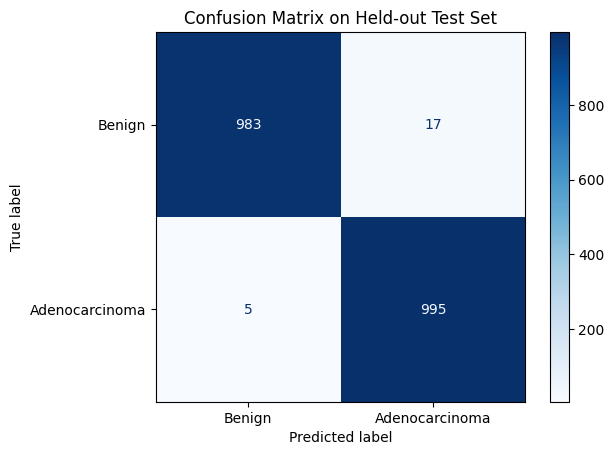


Classification Report:
                precision    recall  f1-score   support

        Benign       0.99      0.98      0.99      1000
Adenocarcinoma       0.98      0.99      0.99      1000

      accuracy                           0.99      2000
     macro avg       0.99      0.99      0.99      2000
  weighted avg       0.99      0.99      0.99      2000



In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Load best model saved during K-Fold
model = ImprovedCNN().to(device)
model.load_state_dict(torch.load("best_kfold_model.pth"))
model.eval()
print("Loaded best model from K-Fold.")

# Inference on the hold-out test set
all_preds = []
all_labels = []

with torch.no_grad():
    for X_test, y_test in test_loader:
        X_test = X_test.to(device)
        y_test = y_test.to(device)

        outputs = model(X_test)
        predicted = torch.argmax(outputs, dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_test.cpu().numpy())

# Compute and plot the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Adenocarcinoma'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix on Held-out Test Set")
plt.show()

# Optional: print classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Benign', 'Adenocarcinoma']))


In [15]:
print(model)

ImprovedCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=4096, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [17]:
import matplotlib.pyplot as plt

def visualize_all_conv_outputs(image_tensor, label_name):
    # Send image through conv layers
    x = image_tensor.unsqueeze(0).to(device)  # shape: [1, 1, 64, 64]
    
    model.eval()
    outputs = []
    names = []

    x = model.pool(F.relu(model.bn1(model.conv1(x))))
    outputs.append(x)
    names.append("Conv1")

    x = model.pool(F.relu(model.bn2(model.conv2(x))))
    outputs.append(x)
    names.append("Conv2")

    x = model.pool(F.relu(model.bn3(model.conv3(x))))
    outputs.append(x)
    names.append("Conv3")

    # Show original image
    plt.figure(figsize=(3, 3))
    plt.imshow(image_tensor.squeeze().cpu().numpy(), cmap='gray')
    plt.title(f"Original Image - {label_name}")
    plt.axis("off")
    plt.show()

    # Plot each conv layer output
    for idx, feature_map in enumerate(outputs):
        feature_map = feature_map.squeeze(0)  # shape: [C, H, W]
        num_filters = feature_map.shape[0]
        cols = 8
        rows = (num_filters + cols - 1) // cols

        fig = plt.figure(figsize=(15, rows * 2))
        for i in range(num_filters):
            ax = fig.add_subplot(rows, cols, i + 1)
            ax.imshow(feature_map[i].cpu().detach().numpy(), cmap='gray')
            ax.axis('off')
            ax.set_title(f'{i}', fontsize=6)

        plt.suptitle(f"{names[idx]} Output: {num_filters} Filters", fontsize=16)
        plt.tight_layout()
        plt.show()


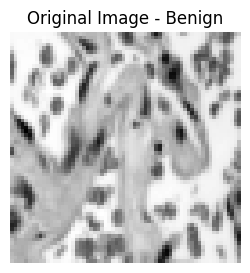

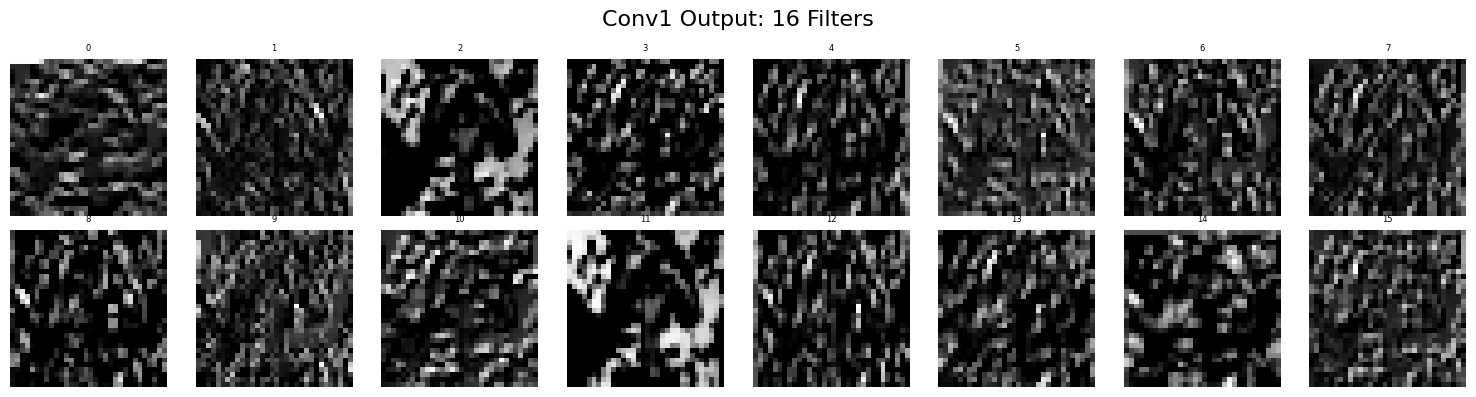

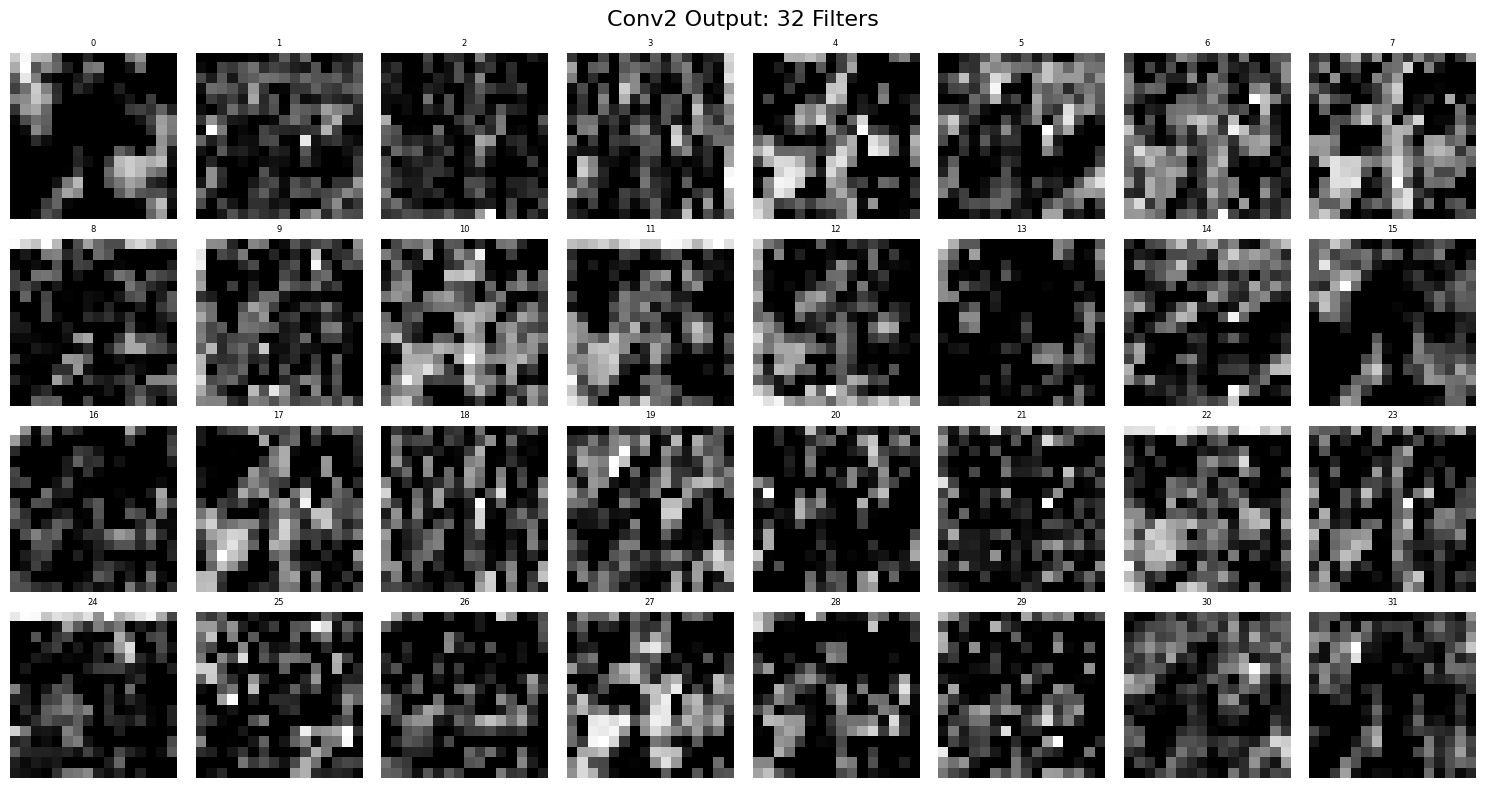

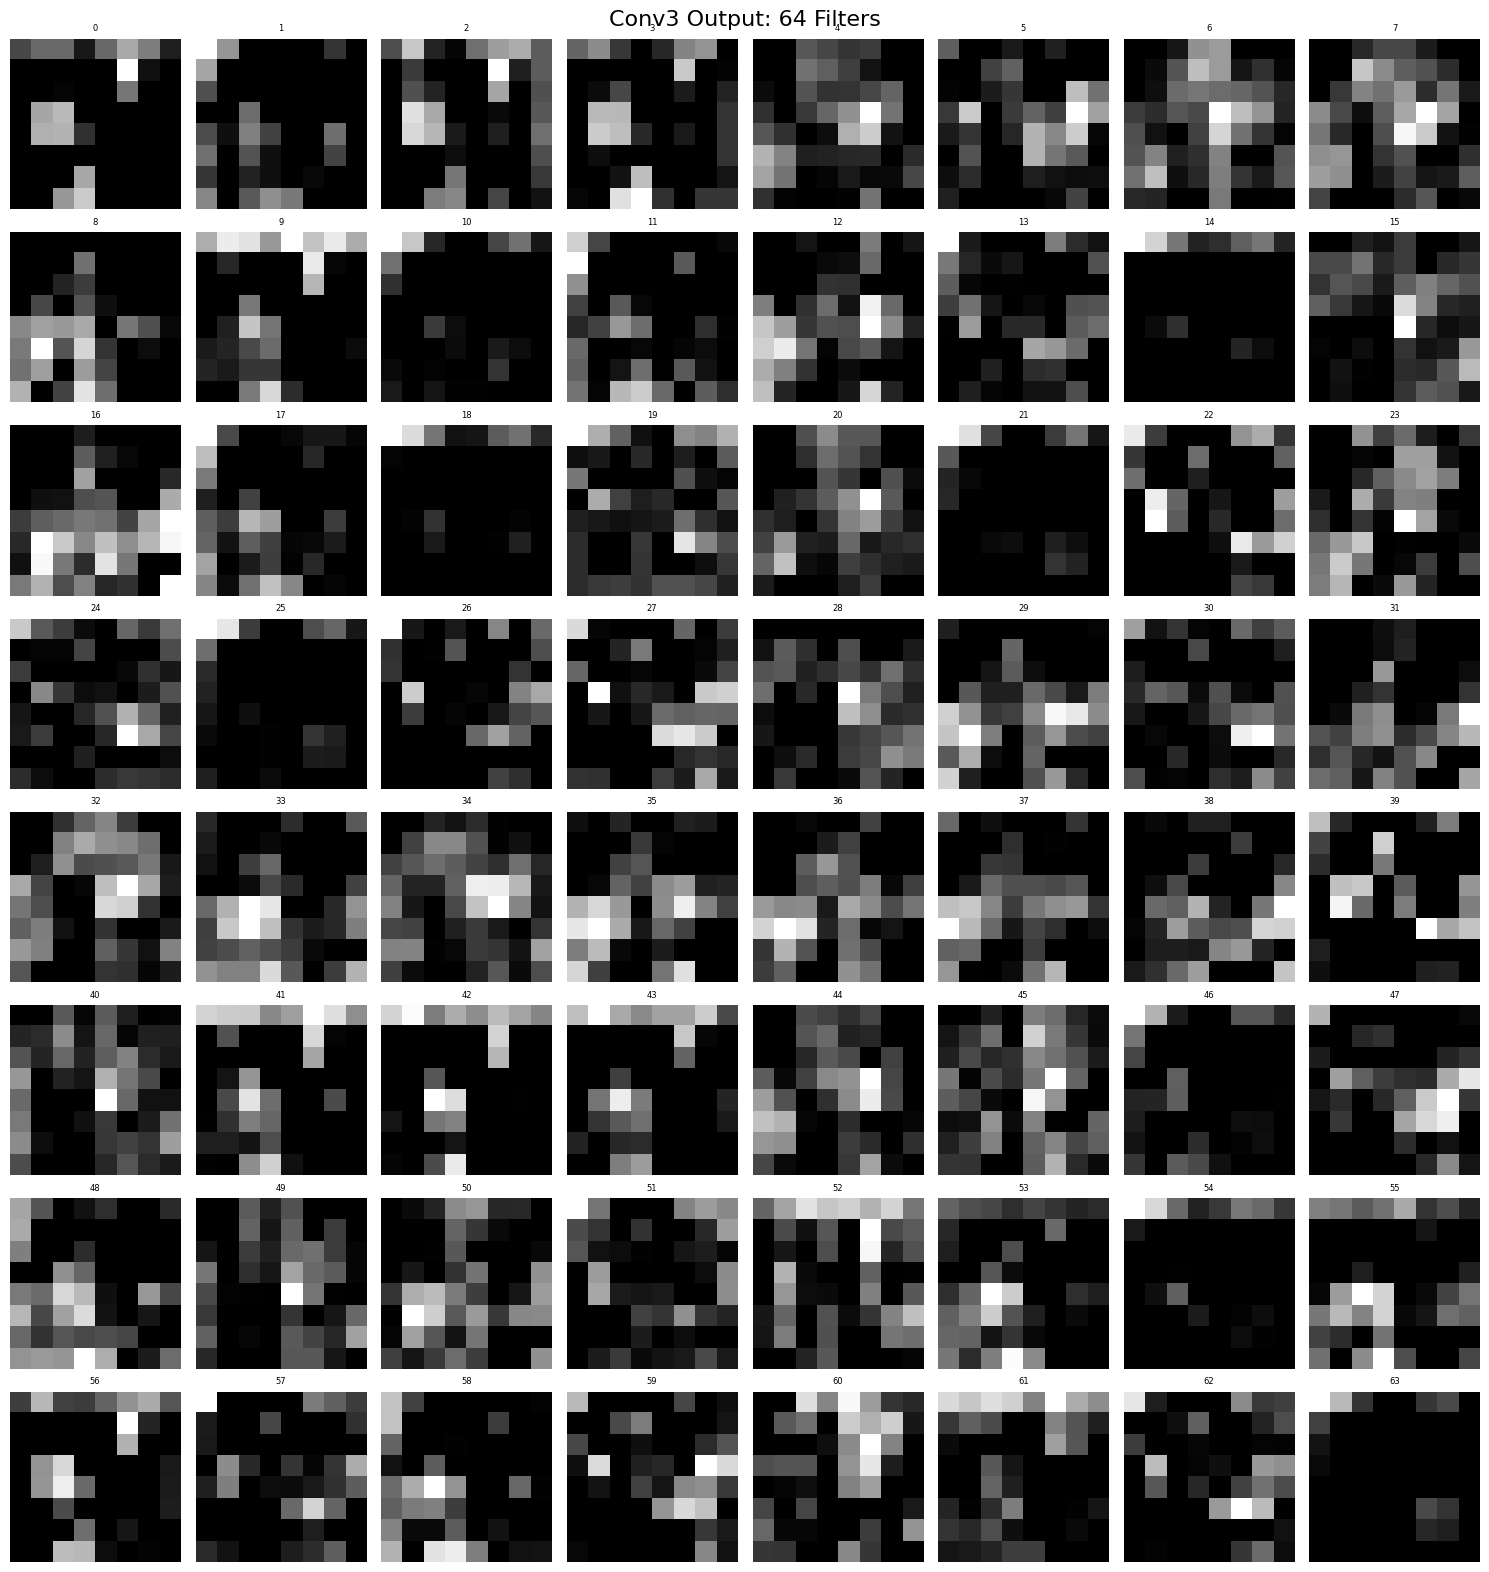

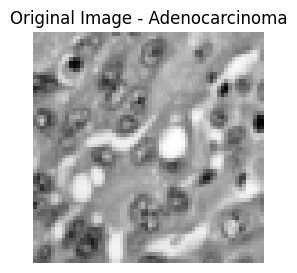

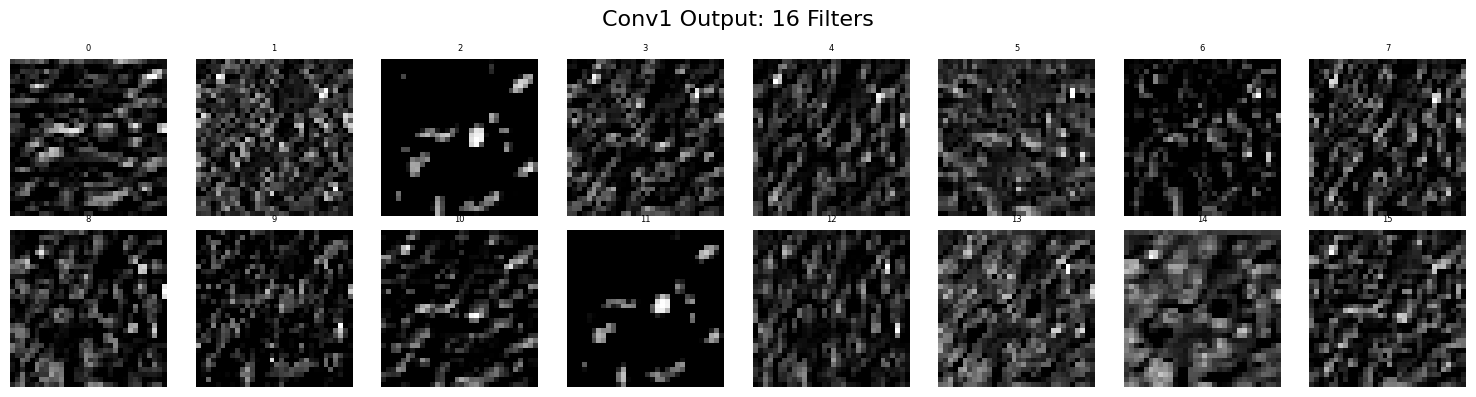

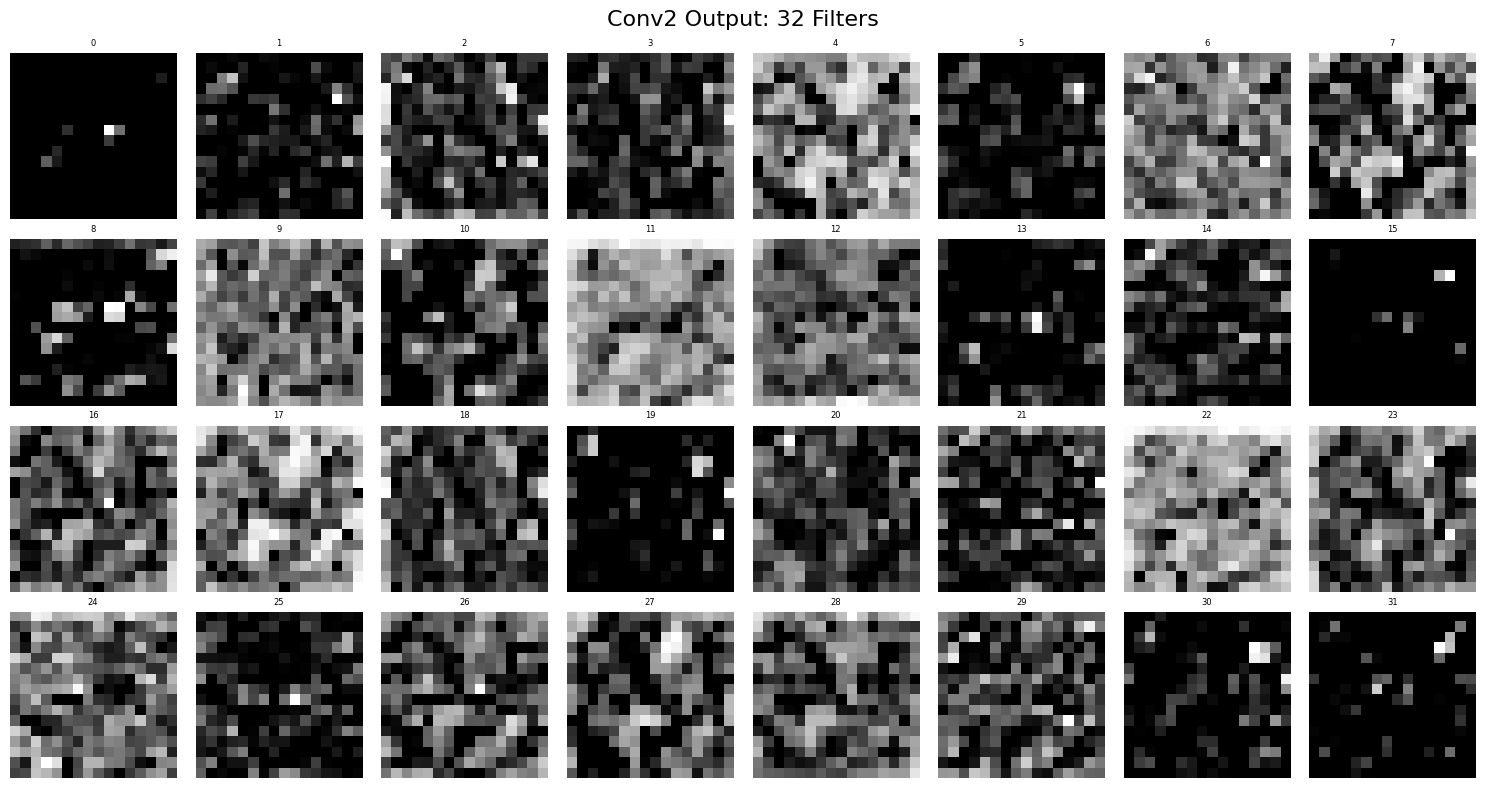

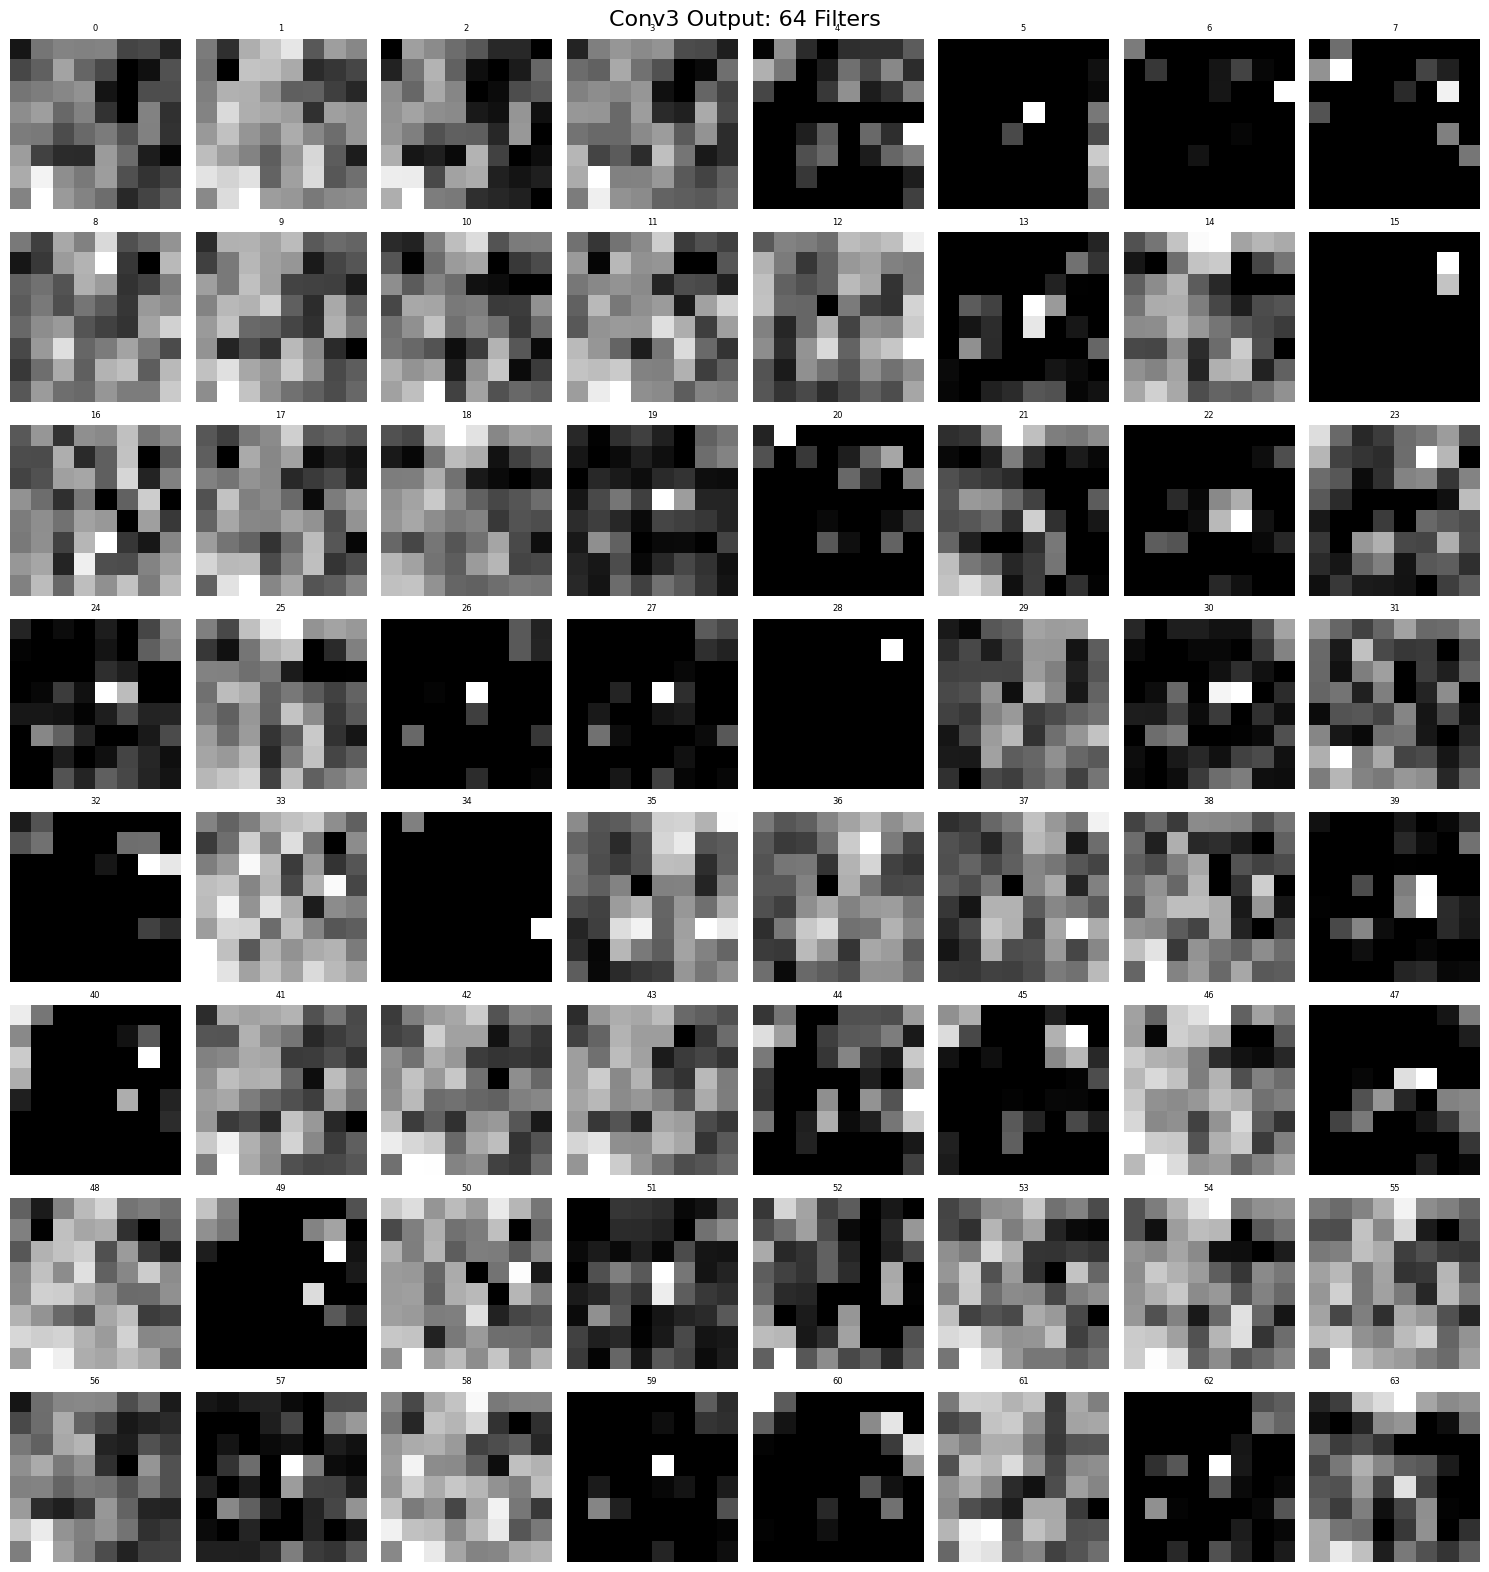

In [18]:
# Find one benign and one adenocarcinoma image
for img, label in train_dataset_full:
    if label == 0:  # Benign
        visualize_all_conv_outputs(img, "Benign")
        break

for img, label in train_dataset_full:
    if label == 1:  # Adenocarcinoma
        visualize_all_conv_outputs(img, "Adenocarcinoma")
        break


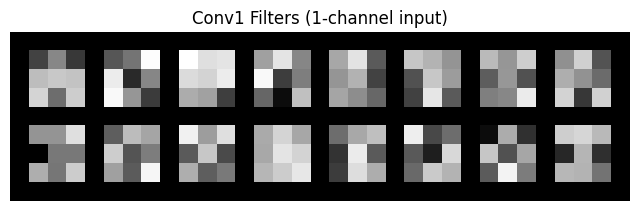

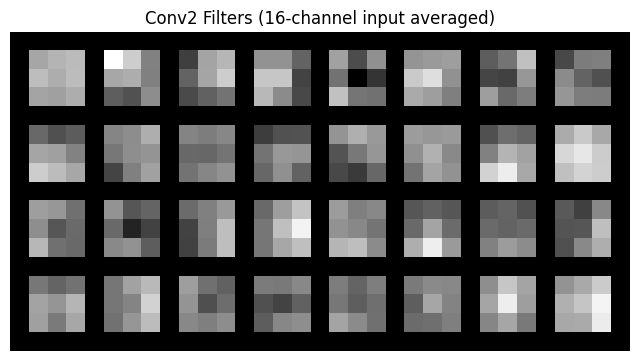

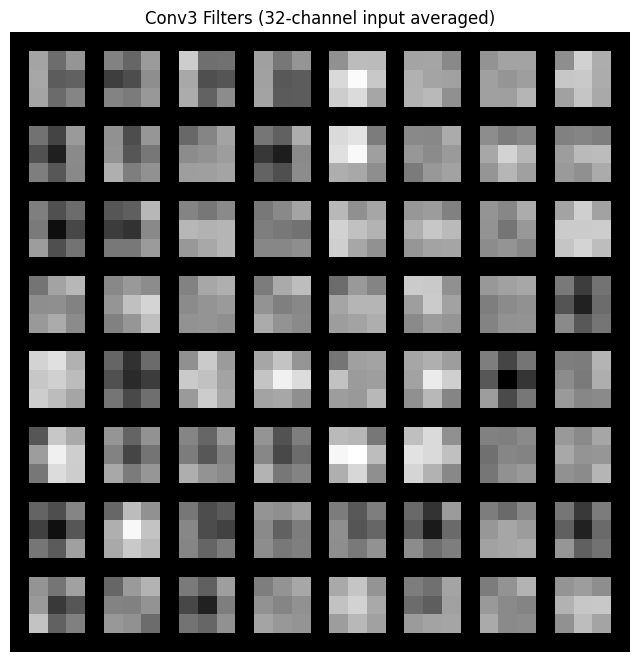

In [19]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

def vis_conv_filters(weight_tensor, title, nrow=8, flatten_input=True):
    """
    Visualize learned conv filters.
    - weight_tensor: shape [out_channels, in_channels, H, W]
    - flatten_input: if True, average across input channels
    """
    weights = weight_tensor.clone().detach().cpu()

    if flatten_input:
        weights = weights.mean(dim=1, keepdim=True)  # shape: [out_channels, 1, H, W]

    grid = make_grid(weights, nrow=nrow, normalize=True, padding=1)
    npimg = grid.numpy()

    plt.figure(figsize=(nrow, weights.shape[0] // nrow + 2))
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Load your trained model
model = ImprovedCNN().to(device)
model.load_state_dict(torch.load("best_kfold_model.pth"))
model.eval()

# Visualize filters from Conv1, Conv2, Conv3
vis_conv_filters(model.conv1.weight, "Conv1 Filters (1-channel input)", nrow=8, flatten_input=True)
vis_conv_filters(model.conv2.weight, "Conv2 Filters (16-channel input averaged)", nrow=8, flatten_input=True)
vis_conv_filters(model.conv3.weight, "Conv3 Filters (32-channel input averaged)", nrow=8, flatten_input=True)


In [22]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
from kymatio.torch import Scattering2D

# Define MPS device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Create scattering object
IMG_SIZE = 64
J = 2
L = 8
scattering = Scattering2D(J=J, shape=(IMG_SIZE, IMG_SIZE), L=L).to(device)

# Define transforms
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Custom Dataset
class ScatteringDataset(Dataset):
    def __init__(self, image_paths, labels, scattering, transform=None, device='cpu'):
        self.image_paths = image_paths
        self.labels = labels
        self.scattering = scattering
        self.transform = transform
        self.device = device

    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # Load image and apply transform
        img = Image.open(img_path).convert('L')
        if self.transform:
            img = self.transform(img)  # [1, 64, 64]

        img = img.to(torch.float32).to(self.device)


        with torch.no_grad():
            Sx = self.scattering(img.unsqueeze(0))  # [1, 81, 16, 16]
            Sx = Sx.squeeze()


        return Sx, label



In [23]:
# Instantiate dataset
scattering_dataset = ScatteringDataset(train_paths, train_labels, scattering, transform=transform, device=device)

# Test it
X, y = scattering_dataset[0]
print("Returned shape:", X.shape)
print("Label:", y)



Returned shape: torch.Size([81, 16, 16])
Label: 0


In [24]:

class ScatNetClassifier(nn.Module):
    def __init__(self, input_dim=81):
        super(ScatNetClassifier, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # Binary classification
        )

    def forward(self, x):

        return self.classifier(x)


In [25]:
# ---- Config ----
k = 5
epochs = 10
batch_size = 64

skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
indices = np.arange(len(train_paths))
labels_np = np.array(train_labels)

fold_accuracies, fold_f1s = [], []
train_losses_per_epoch, val_losses_per_epoch = [], []
train_accs_per_epoch, val_accs_per_epoch = [], []

# ---- Use only mean pooled features: size [81] ----
input_dim = 81
model_class = ScatNetClassifier(input_dim=input_dim)

for fold, (train_idx, val_idx) in enumerate(skf.split(indices, labels_np)):
    print(f"\n--- Fold {fold+1} ---")

    train_subset = Subset(scattering_dataset, train_idx)
    val_subset = Subset(scattering_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    # New model per fold
    model = ScatNetClassifier(input_dim=input_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0.0, 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # --- Average pooling over spatial dims ---
            X_batch = X_batch.mean(dim=(-1, -2))  # [batch_size, 81]

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_correct += (outputs.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)

        avg_train_loss = train_loss / total
        train_acc = train_correct / total
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)

        # ---- Validation ----
        model.eval()
        val_loss, val_correct = 0.0, 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                X_batch = X_batch.mean(dim=(-1, -2))  # [batch_size, 81]

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item() * X_batch.size(0)
                val_correct += (outputs.argmax(1) == y_batch).sum().item()
                all_preds.extend(outputs.argmax(1).cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

        avg_val_loss = val_loss / len(val_subset)
        val_acc = val_correct / len(val_subset)
        val_f1 = f1_score(all_labels, all_preds, average='weighted')
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, "
              f"Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f}, "
              f"Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    fold_accuracies.append(val_acc)
    fold_f1s.append(val_f1)
    train_losses_per_epoch.append(train_losses)
    val_losses_per_epoch.append(val_losses)
    train_accs_per_epoch.append(train_accs)
    val_accs_per_epoch.append(val_accs)

# ---- Summary ----
print(f"\nMean Accuracy across {k} folds: {np.mean(fold_accuracies):.4f}")
print(f"Mean F1 Score across {k} folds: {np.mean(fold_f1s):.4f}")



--- Fold 1 ---
Epoch 1/10 - Train Loss: 0.6184, Train Acc: 0.7505 | Val Loss: 0.4542, Val Acc: 0.8456, Val F1: 0.8448
Epoch 2/10 - Train Loss: 0.4015, Train Acc: 0.8344 | Val Loss: 0.3655, Val Acc: 0.8475, Val F1: 0.8456
Epoch 3/10 - Train Loss: 0.3574, Train Acc: 0.8508 | Val Loss: 0.3375, Val Acc: 0.8625, Val F1: 0.8617
Epoch 4/10 - Train Loss: 0.3392, Train Acc: 0.8597 | Val Loss: 0.3243, Val Acc: 0.8644, Val F1: 0.8635
Epoch 5/10 - Train Loss: 0.3239, Train Acc: 0.8653 | Val Loss: 0.3124, Val Acc: 0.8738, Val F1: 0.8732
Epoch 6/10 - Train Loss: 0.3180, Train Acc: 0.8733 | Val Loss: 0.3106, Val Acc: 0.8712, Val F1: 0.8705
Epoch 7/10 - Train Loss: 0.3096, Train Acc: 0.8744 | Val Loss: 0.3028, Val Acc: 0.8800, Val F1: 0.8797
Epoch 8/10 - Train Loss: 0.2991, Train Acc: 0.8791 | Val Loss: 0.3018, Val Acc: 0.8788, Val F1: 0.8780
Epoch 9/10 - Train Loss: 0.3000, Train Acc: 0.8773 | Val Loss: 0.2964, Val Acc: 0.8800, Val F1: 0.8794
Epoch 10/10 - Train Loss: 0.2941, Train Acc: 0.8819 | Val

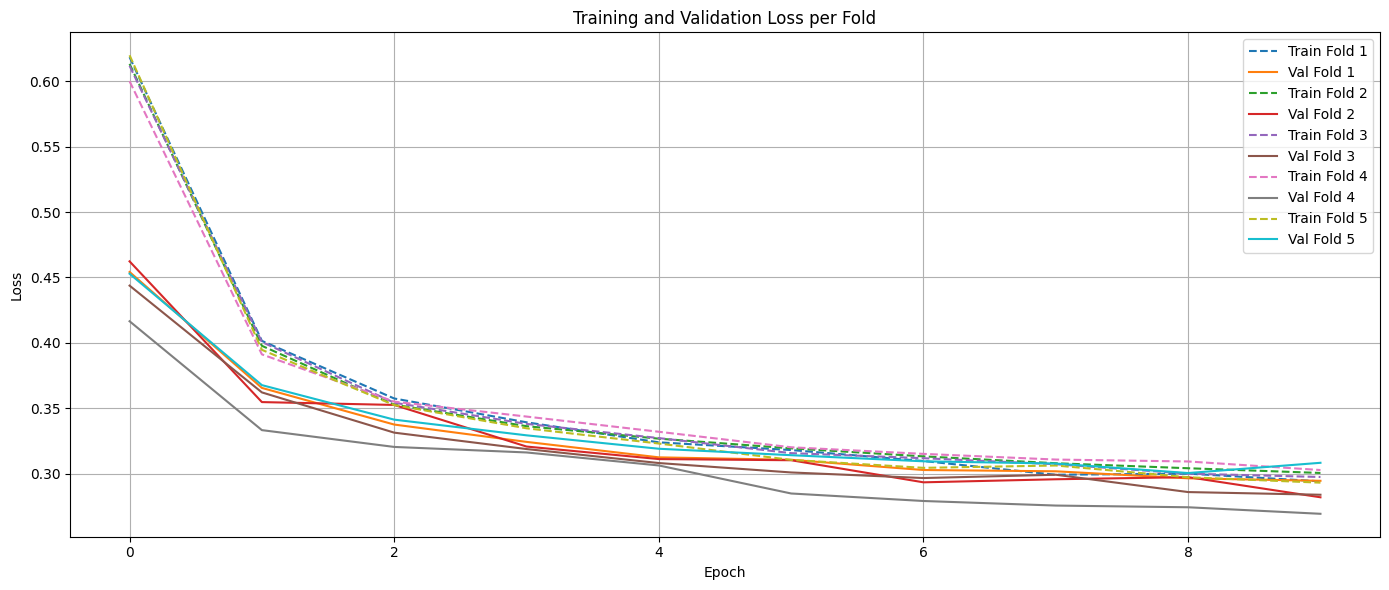

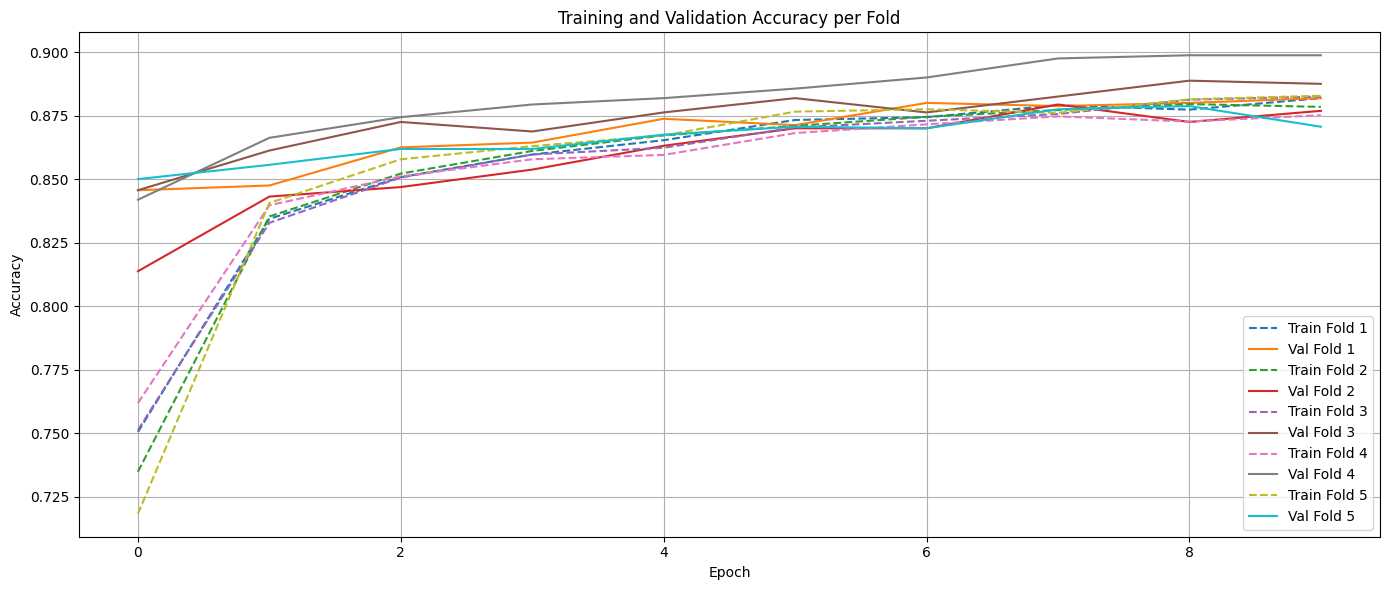

In [26]:
import matplotlib.pyplot as plt

# ---- Plotting Loss Curves ----
plt.figure(figsize=(14, 6))
for i in range(k):
    plt.plot(train_losses_per_epoch[i], label=f"Train Fold {i+1}", linestyle='--')
    plt.plot(val_losses_per_epoch[i], label=f"Val Fold {i+1}")
plt.title("Training and Validation Loss per Fold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Plotting Accuracy Curves ----
plt.figure(figsize=(14, 6))
for i in range(k):
    plt.plot(train_accs_per_epoch[i], label=f"Train Fold {i+1}", linestyle='--')
    plt.plot(val_accs_per_epoch[i], label=f"Val Fold {i+1}")
plt.title("Training and Validation Accuracy per Fold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Visualizing features for class: 0
Scattering output shape: torch.Size([1, 1, 81, 16, 16])


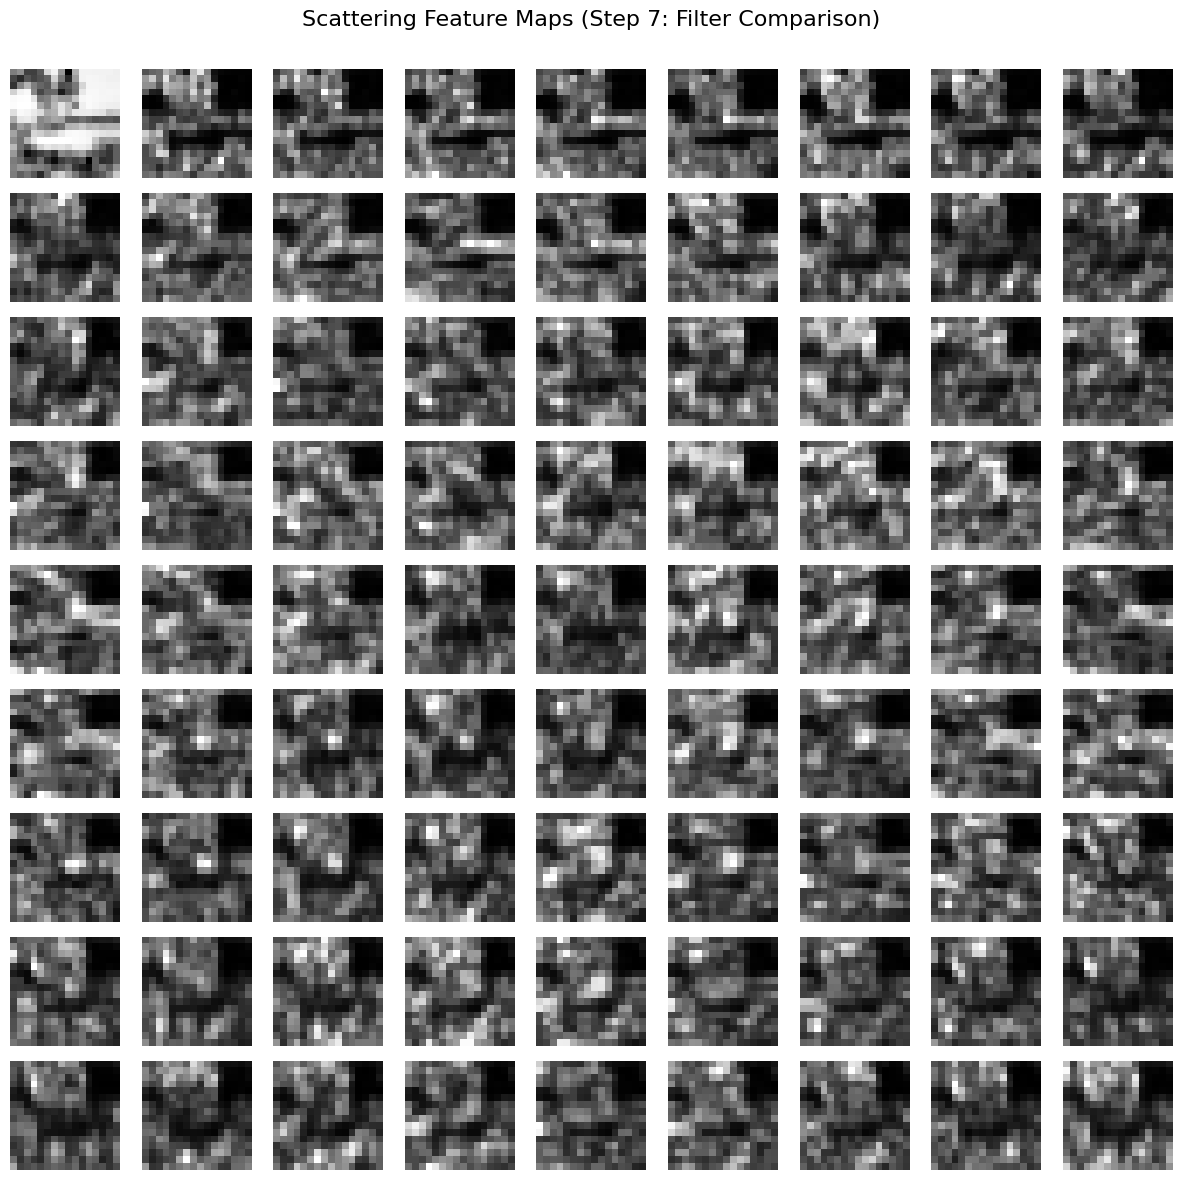

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_iter = iter(test_loader)
images, labels = next(data_iter)

# Select first image
img_tensor = images[0].unsqueeze(0).to(device) # Shape: [1, 1, 64, 64]
print(f"Visualizing features for class: {labels[0].item()}")


x = img_tensor 

#  Step 2: Define Scattering Transform -----

J = 2
L = 8
scattering = Scattering2D(J=J, shape=(64, 64), L=L).to(device)
x = x.to(device) 

# Run Scattering
Sx = scattering(x) # Output: [1, C, 16, 16]
print("Scattering output shape:", Sx.shape)

Sx_np = Sx.squeeze().cpu().numpy() # shape: (81, 16, 16)

# Visualize 
# Create a grid of 9 rows x 9 columns = 81 channels
fig, axs = plt.subplots(9, 9, figsize=(12, 12))
fig.suptitle("Scattering Feature Maps (Step 7: Filter Comparison)", fontsize=16)

for i in range(81):
    ax = axs[i // 9, i % 9]
    ax.imshow(Sx_np[i], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

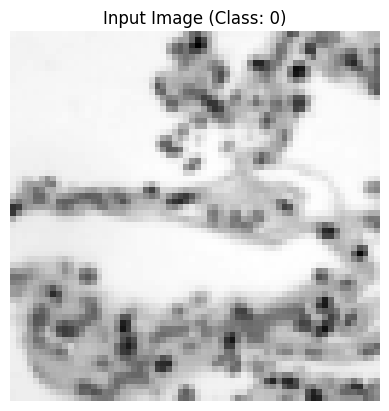

In [28]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get a batch of images from the test_loader
data_iter = iter(test_loader)
images, labels = next(data_iter)

# Select the first image in the batch
idx = 0 
img_tensor = images[idx].unsqueeze(0).to(device) # Shape: [1, 1, 64, 64]
label_idx = labels[idx].item()

# Convert to numpy for visualization
img_np = img_tensor.squeeze().cpu().numpy()

# Visualize
plt.imshow(img_np, cmap='gray')
plt.title(f"Input Image (Class: {label_idx})")
plt.axis('off')
plt.show()

x = img_tensor

In [29]:
# Average each feature map (16x16) → single scalar
feature_vector = Sx.mean(dim=(-1, -2))  # shape: [1, 81]
feature_vector = feature_vector.squeeze(0)  # shape: [81]
print("Final feature vector shape:", feature_vector.shape)
feature_vector


Final feature vector shape: torch.Size([1, 81])


tensor([[0.3292, 0.0234, 0.0253, 0.0279, 0.0284, 0.0272, 0.0251, 0.0234, 0.0225,
         0.0305, 0.0354, 0.0418, 0.0440, 0.0389, 0.0343, 0.0329, 0.0309, 0.0037,
         0.0033, 0.0031, 0.0028, 0.0026, 0.0027, 0.0030, 0.0037, 0.0039, 0.0040,
         0.0038, 0.0034, 0.0028, 0.0027, 0.0029, 0.0036, 0.0033, 0.0040, 0.0046,
         0.0044, 0.0034, 0.0029, 0.0028, 0.0030, 0.0027, 0.0033, 0.0044, 0.0047,
         0.0039, 0.0032, 0.0030, 0.0029, 0.0025, 0.0029, 0.0037, 0.0041, 0.0040,
         0.0038, 0.0035, 0.0031, 0.0026, 0.0027, 0.0030, 0.0033, 0.0036, 0.0038,
         0.0036, 0.0033, 0.0028, 0.0027, 0.0028, 0.0029, 0.0032, 0.0034, 0.0036,
         0.0033, 0.0032, 0.0030, 0.0028, 0.0027, 0.0027, 0.0027, 0.0029, 0.0035]],
       device='cuda:0')

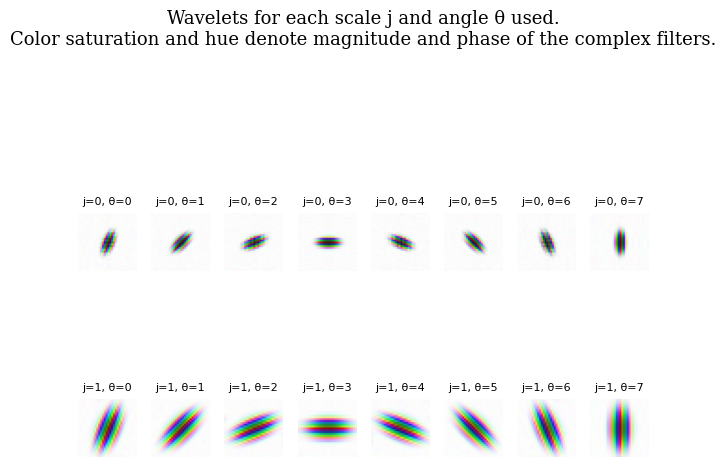

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2
from kymatio.scattering2d.filter_bank import filter_bank
from colorsys import hls_to_rgb

# -------- Custom colorize function --------
def colorize(z):
    n, m = z.shape
    c = np.zeros((n, m, 3))
    c[np.isinf(z)] = (1.0, 1.0, 1.0)
    c[np.isnan(z)] = (0.5, 0.5, 0.5)

    idx = ~(np.isinf(z) + np.isnan(z))
    A = (np.angle(z[idx]) + np.pi) / (2 * np.pi)
    A = (A + 0.5) % 1.0
    B = 1.0 / (1.0 + abs(z[idx]) ** 0.3)
    c[idx] = [hls_to_rgb(a, b, 0.8) for a, b in zip(A, B)]
    return c

# -------- Filter Parameters --------
M = 32
J = 2
L = 8

filters_set = filter_bank(M, M, J, L=L)

# -------- Plot wavelet filters --------
fig, axs = plt.subplots(J, L, sharex=True, sharey=True)
fig.set_figheight(6)
fig.set_figwidth(6)
plt.rc('font', family='serif')

i = 0
for filt in filters_set['psi']:
    f = filt["levels"][0]
    filter_c = fft2(f)
    filter_c = np.fft.fftshift(filter_c)
    axs[i // L, i % L].imshow(colorize(filter_c))
    axs[i // L, i % L].axis('off')
    axs[i // L, i % L].set_title(f"j={i // L}, θ={i % L}", fontsize=8)
    i += 1

fig.suptitle((
    "Wavelets for each scale j and angle θ used.\n"
    "Color saturation and hue denote magnitude and phase of the complex filters."
), fontsize=13)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


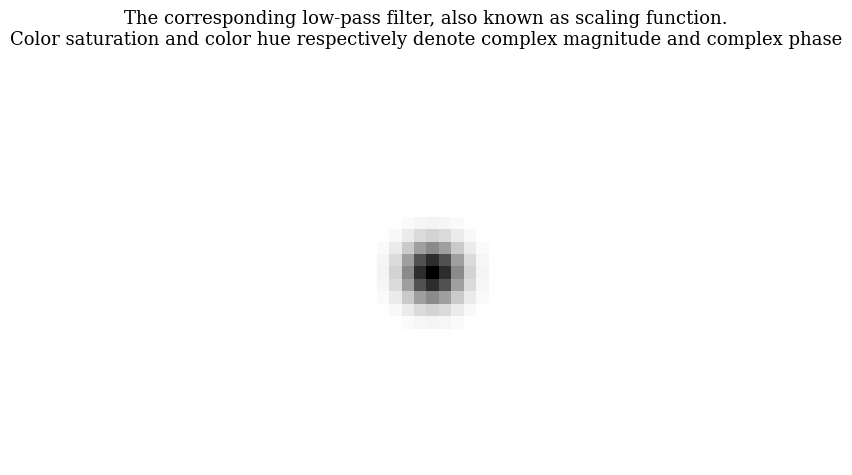

In [31]:
plt.figure()
#plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.axis('off')
plt.set_cmap('gray_r')

f = filters_set['phi']["levels"][0]

filter_c = fft2(f)
filter_c = np.fft.fftshift(filter_c)
plt.suptitle(("The corresponding low-pass filter, also known as scaling "
              "function.\nColor saturation and color hue respectively denote "
              "complex magnitude and complex phase"), fontsize=13)
filter_c = np.abs(filter_c)
plt.imshow(filter_c)

plt.tight_layout()
plt.show()

In [32]:
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initialize the model structure
try:
    best_model_cnn = ImprovedCNN().to(device)
except NameError:
    print("Warning: 'ImprovedCNN' class not found. Trying to use 'model' from memory...")
    # This assumes 'model' is currently in memory from training
    best_model_cnn = model.to(device)

checkpoint_path = 'best_kfold_model.pth'  

if os.path.exists(checkpoint_path):
    best_model_cnn.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"Success! Loaded best model (Fold 3, ~99.56% Acc) from {checkpoint_path}")
else:
    print(f"Warning: '{checkpoint_path}' not found. Using current model state in memory.")

best_model_cnn.eval()

Success! Loaded best model (Fold 3, ~99.56% Acc) from best_kfold_model.pth


ImprovedCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=4096, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=2, bias=True)
  )
)


Processing 10 images for class: Benign
  Image 1/10...


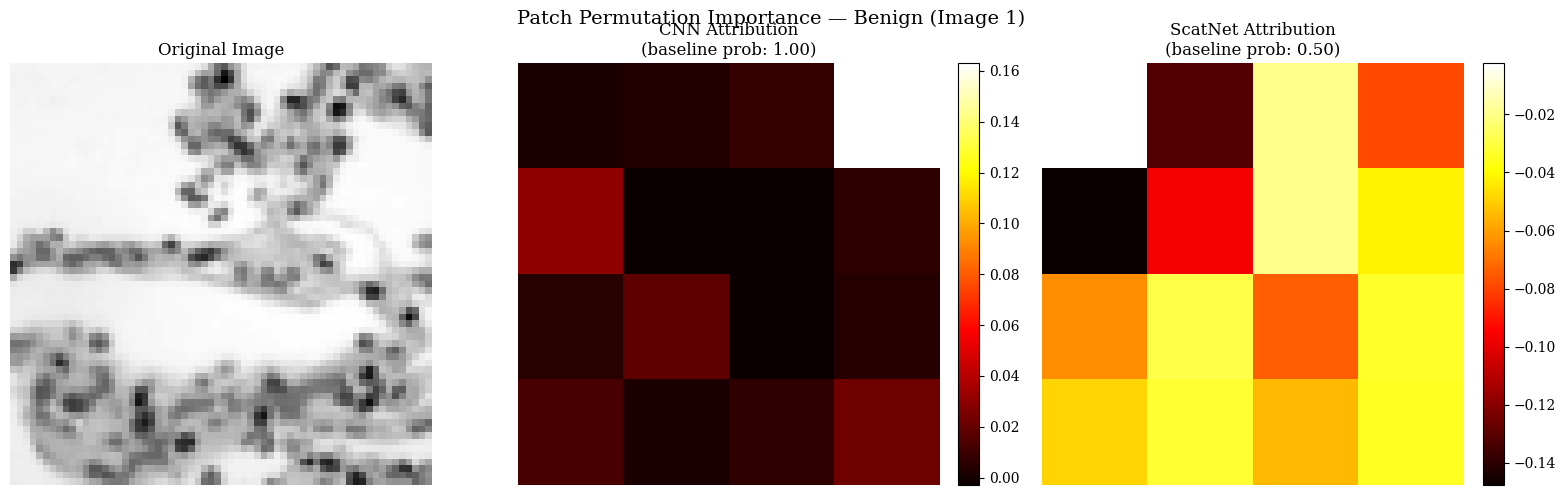

  Saved: xai_results/patch_permutation_benign_01.png
  Image 2/10...


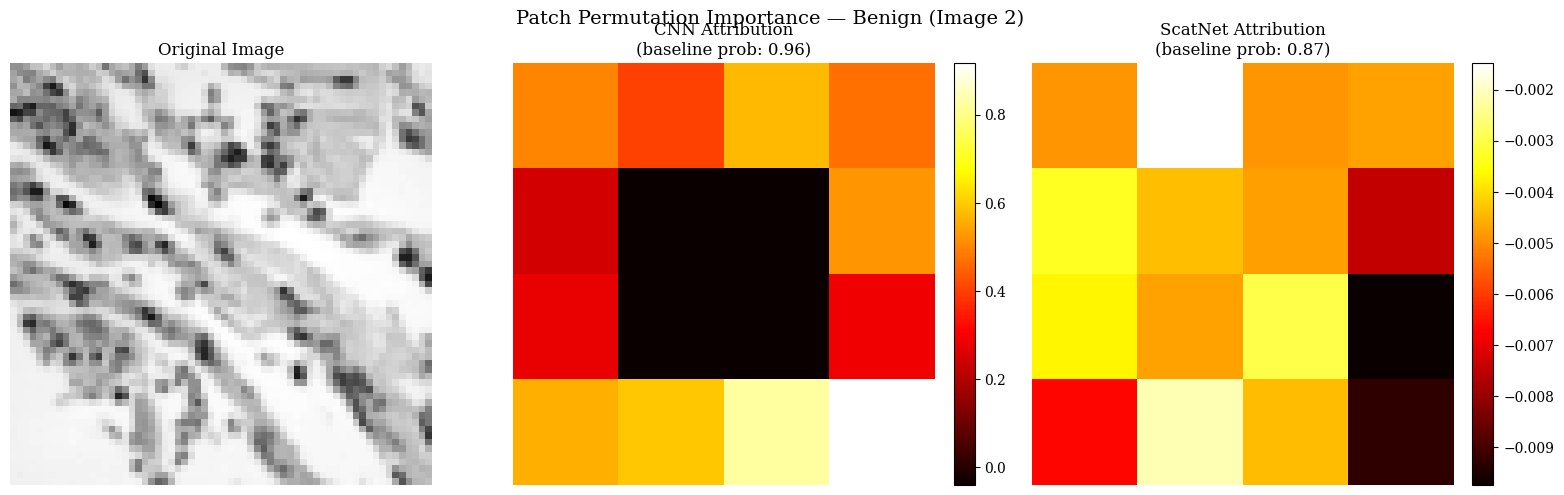

  Saved: xai_results/patch_permutation_benign_02.png
  Image 3/10...


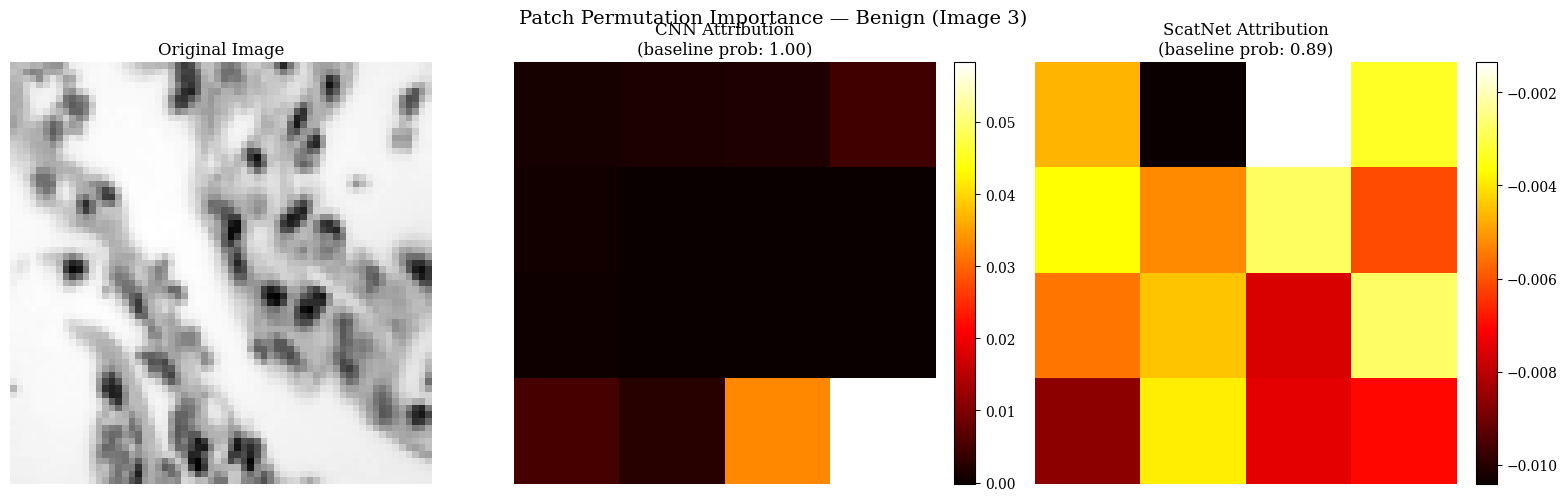

  Saved: xai_results/patch_permutation_benign_03.png
  Image 4/10...


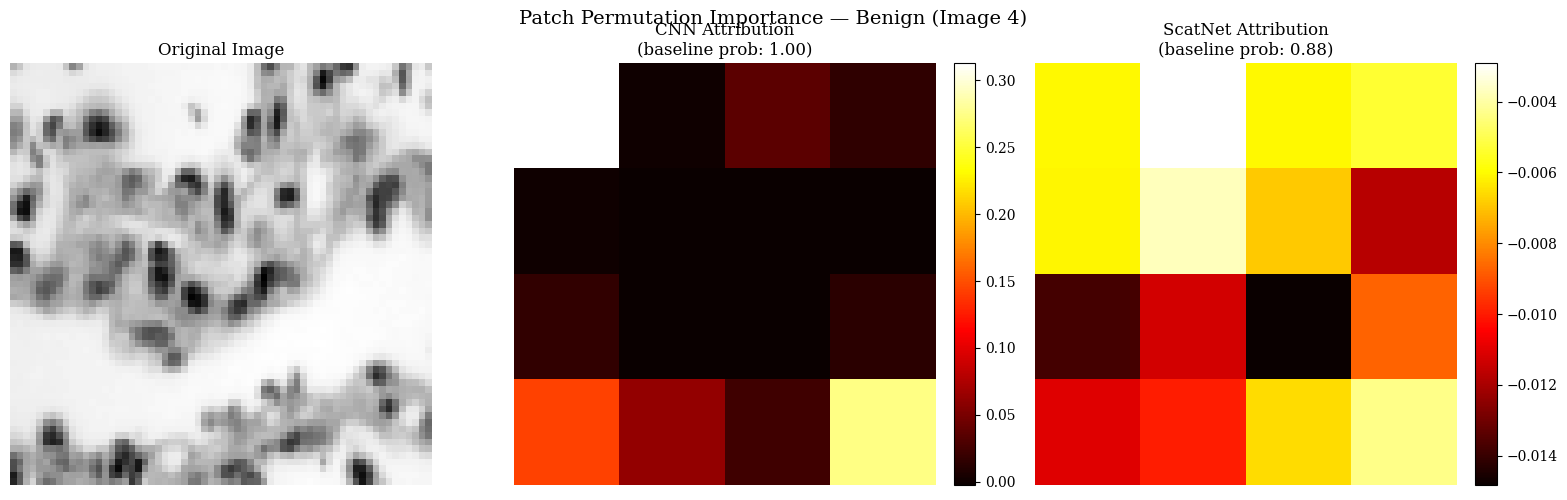

  Saved: xai_results/patch_permutation_benign_04.png
  Image 5/10...


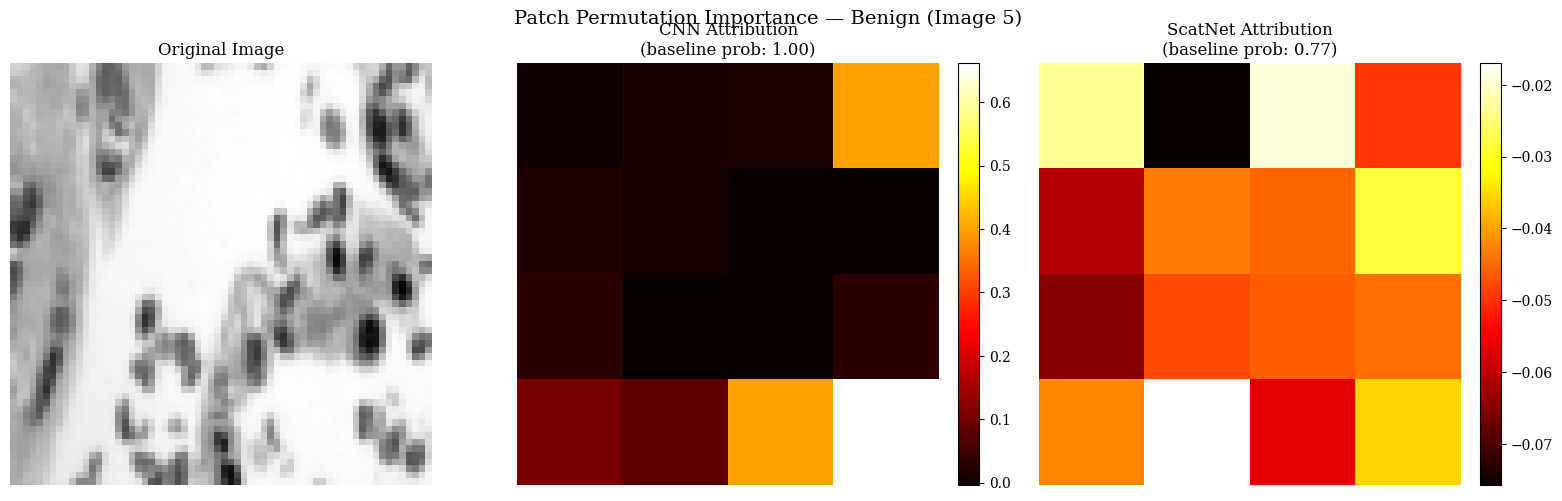

  Saved: xai_results/patch_permutation_benign_05.png
  Image 6/10...


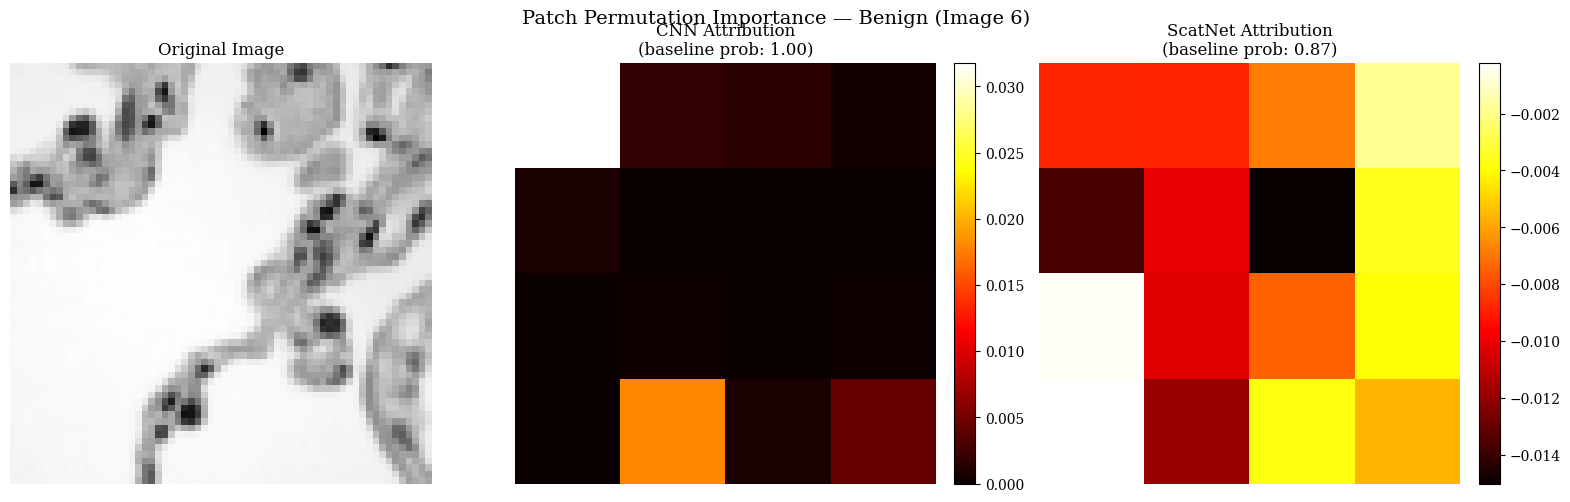

  Saved: xai_results/patch_permutation_benign_06.png
  Image 7/10...


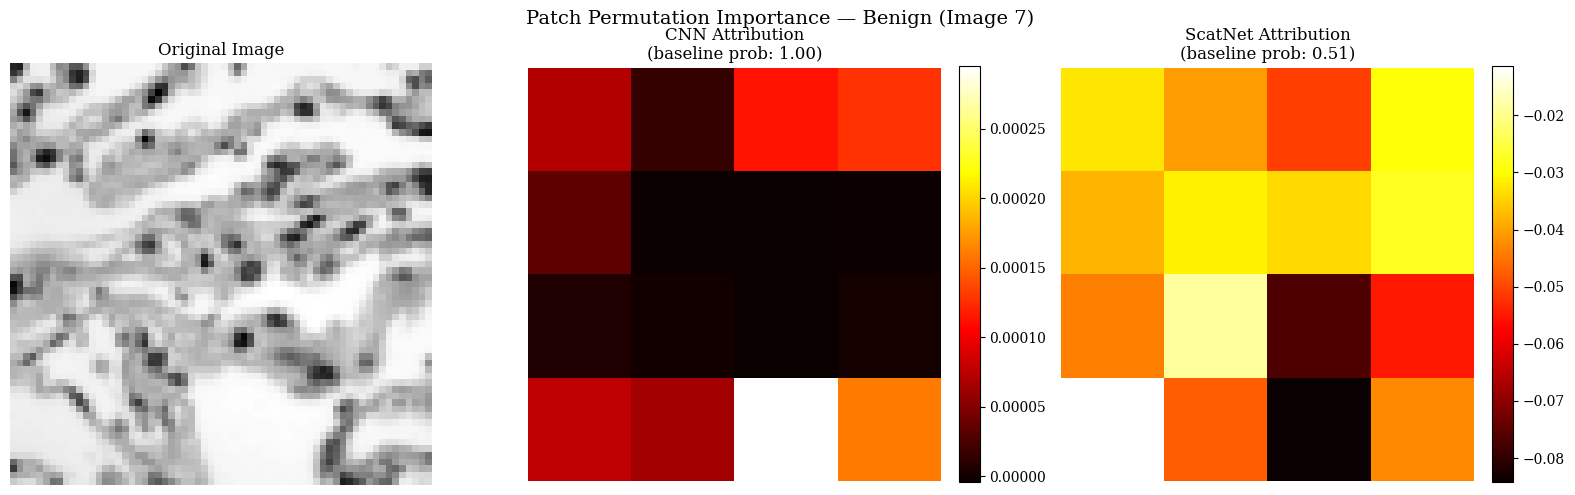

  Saved: xai_results/patch_permutation_benign_07.png
  Image 8/10...


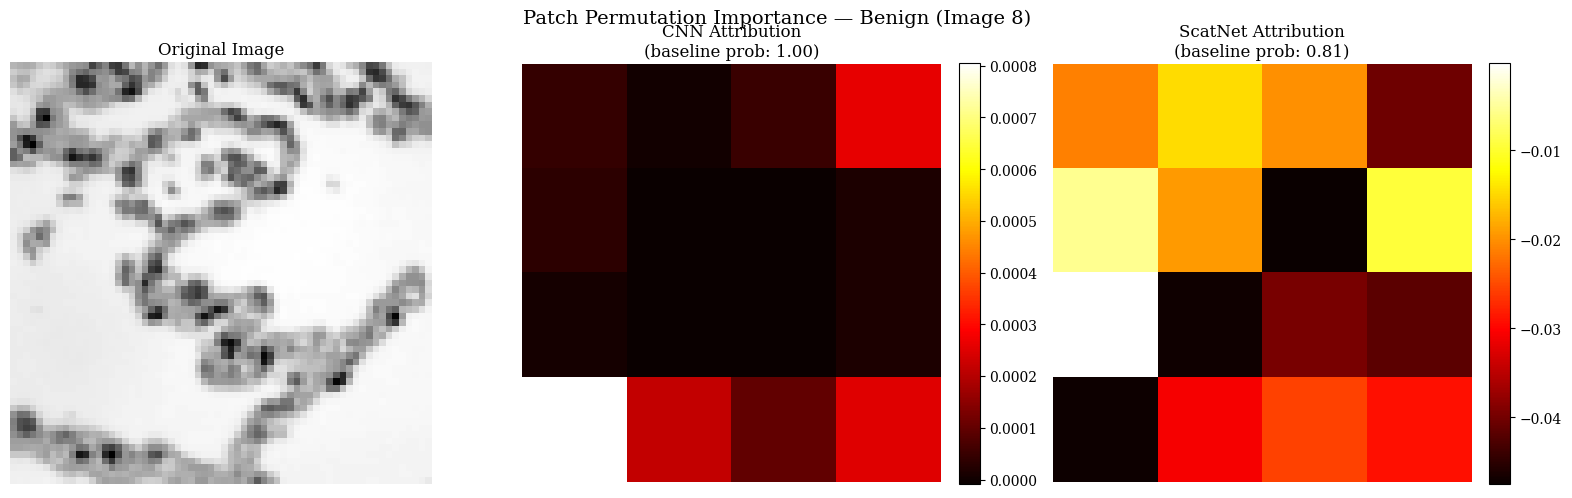

  Saved: xai_results/patch_permutation_benign_08.png
  Image 9/10...


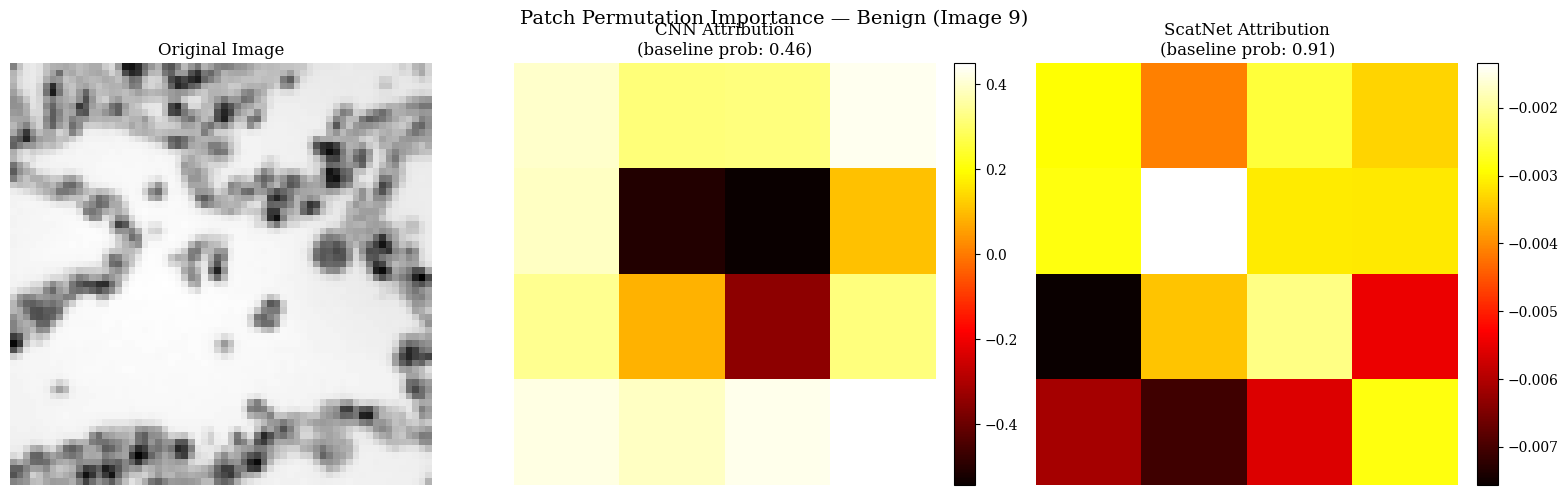

  Saved: xai_results/patch_permutation_benign_09.png
  Image 10/10...


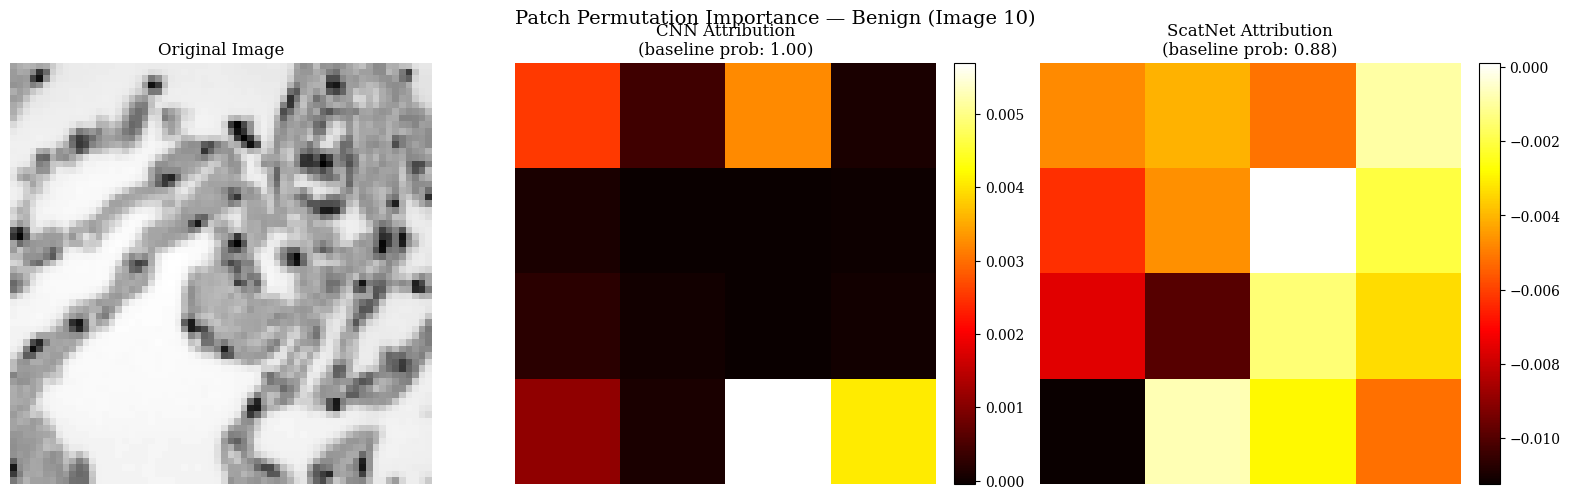

  Saved: xai_results/patch_permutation_benign_10.png

Processing 10 images for class: Adenocarcinoma
  Image 1/10...


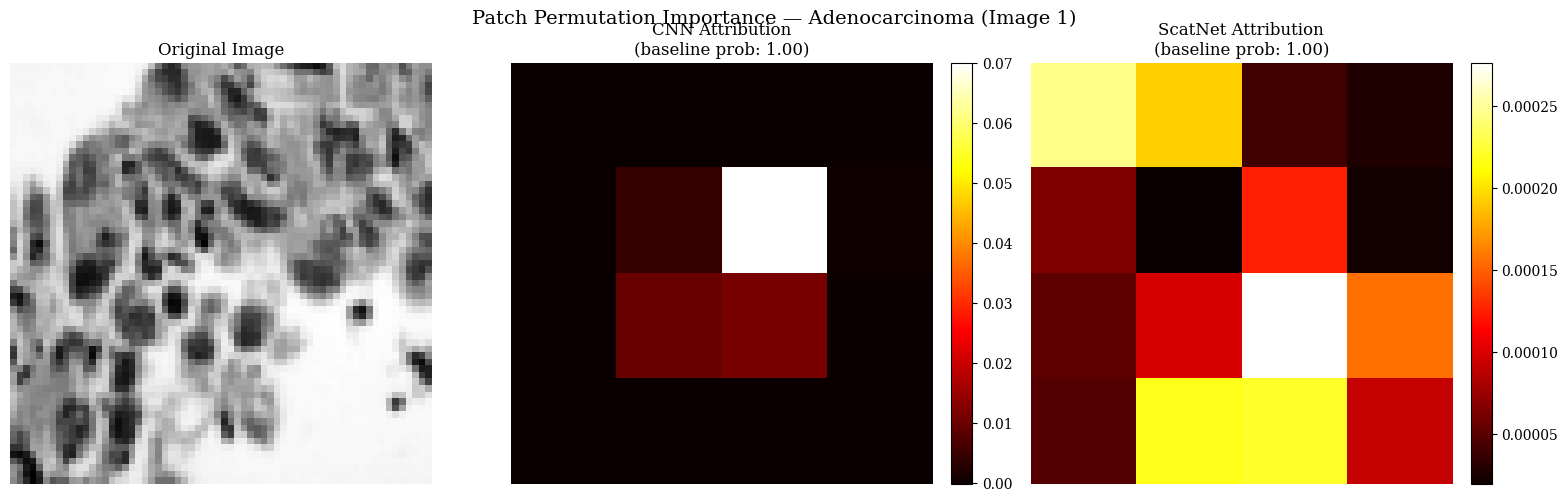

  Saved: xai_results/patch_permutation_adenocarcinoma_01.png
  Image 2/10...


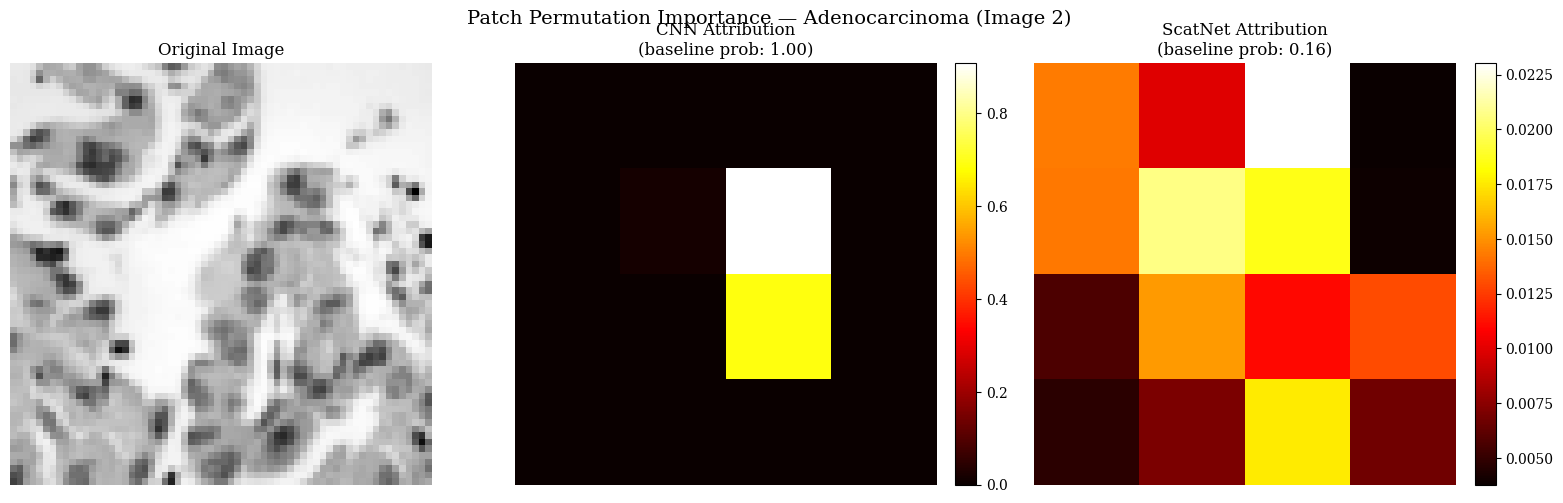

  Saved: xai_results/patch_permutation_adenocarcinoma_02.png
  Image 3/10...


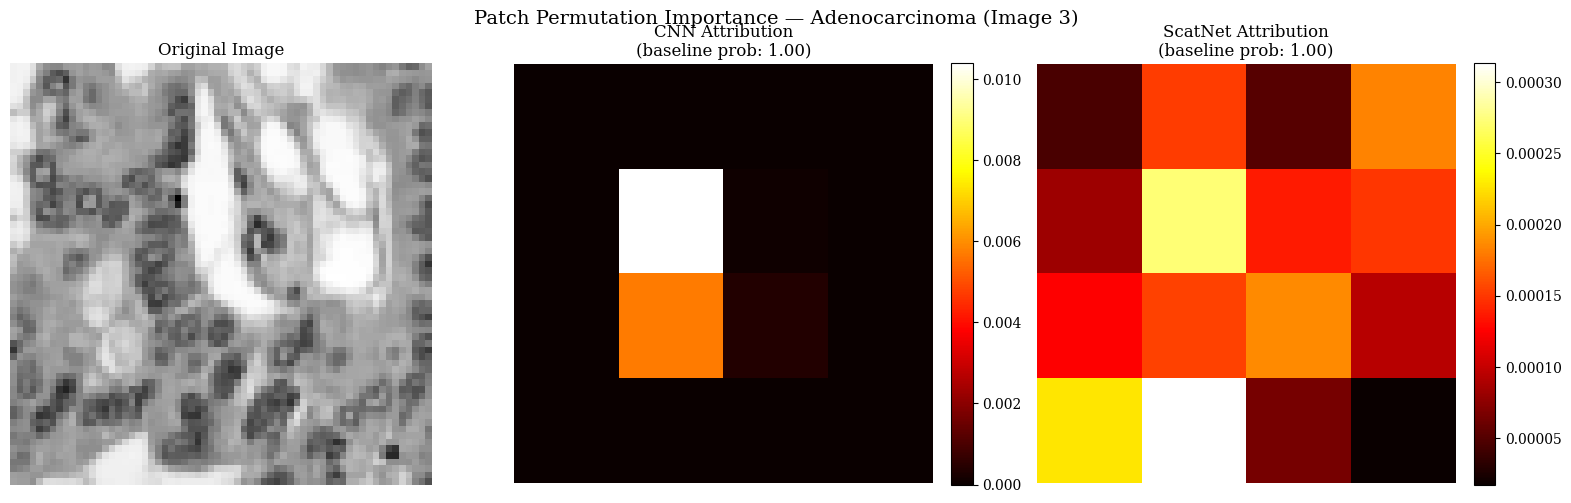

  Saved: xai_results/patch_permutation_adenocarcinoma_03.png
  Image 4/10...


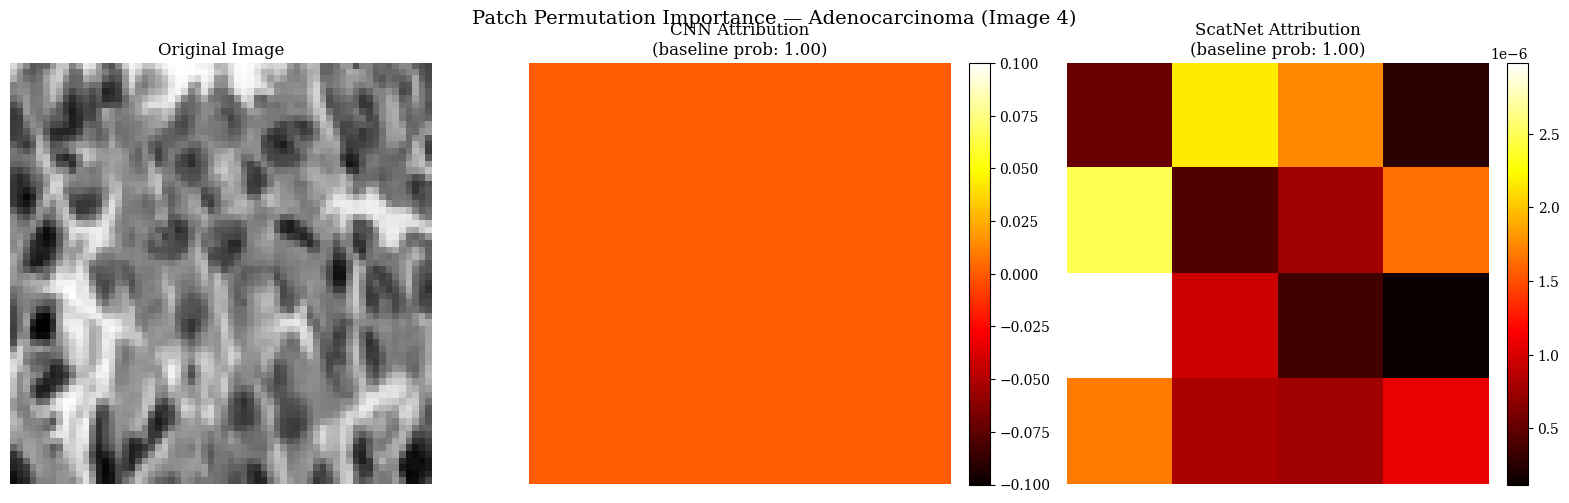

  Saved: xai_results/patch_permutation_adenocarcinoma_04.png
  Image 5/10...


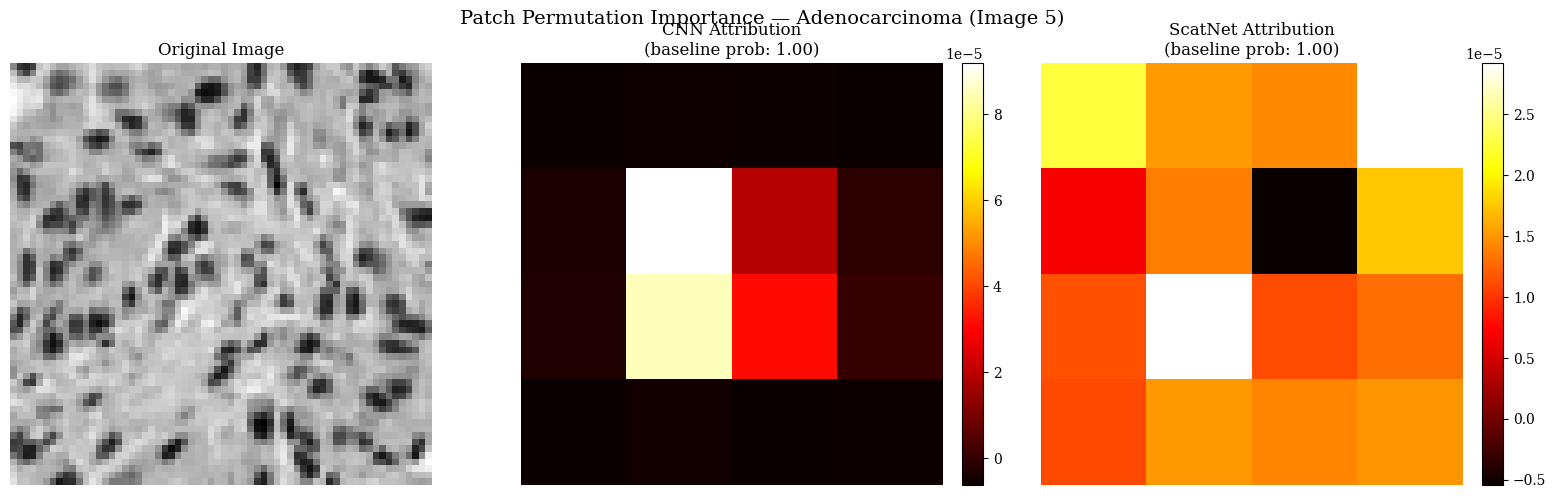

  Saved: xai_results/patch_permutation_adenocarcinoma_05.png
  Image 6/10...


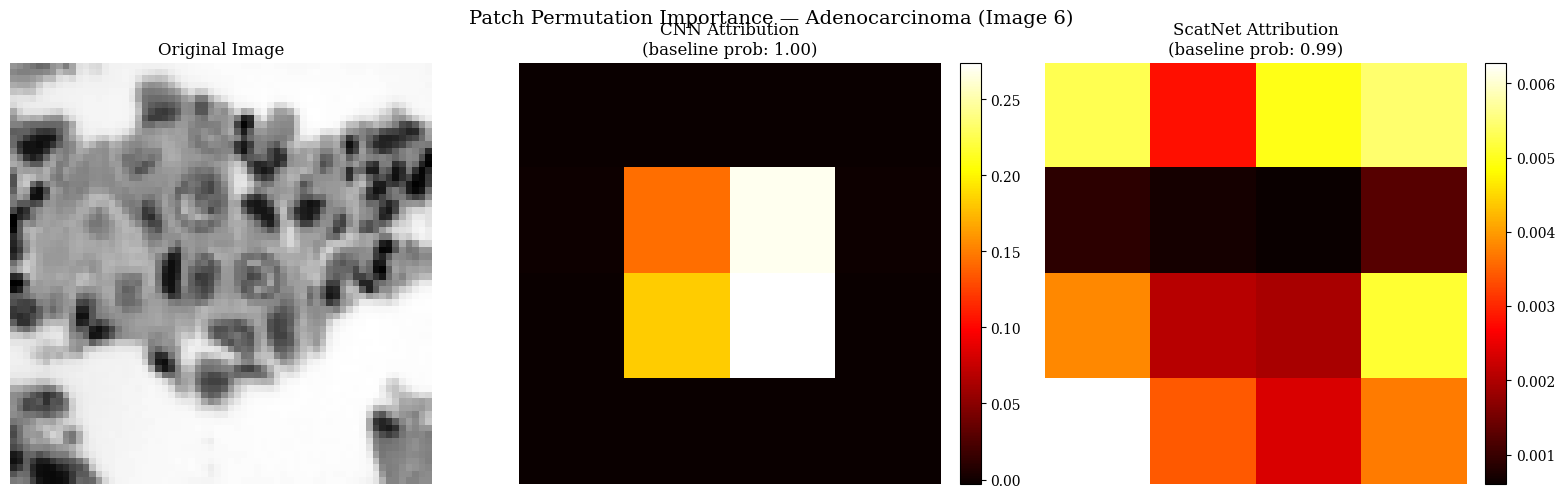

  Saved: xai_results/patch_permutation_adenocarcinoma_06.png
  Image 7/10...


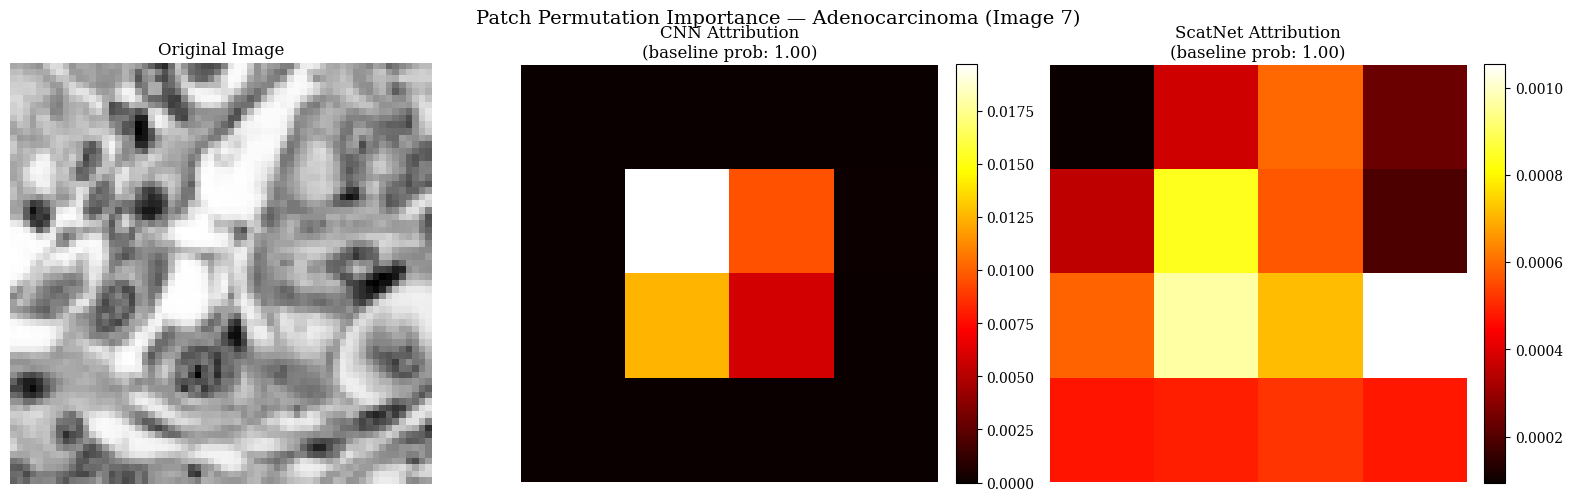

  Saved: xai_results/patch_permutation_adenocarcinoma_07.png
  Image 8/10...


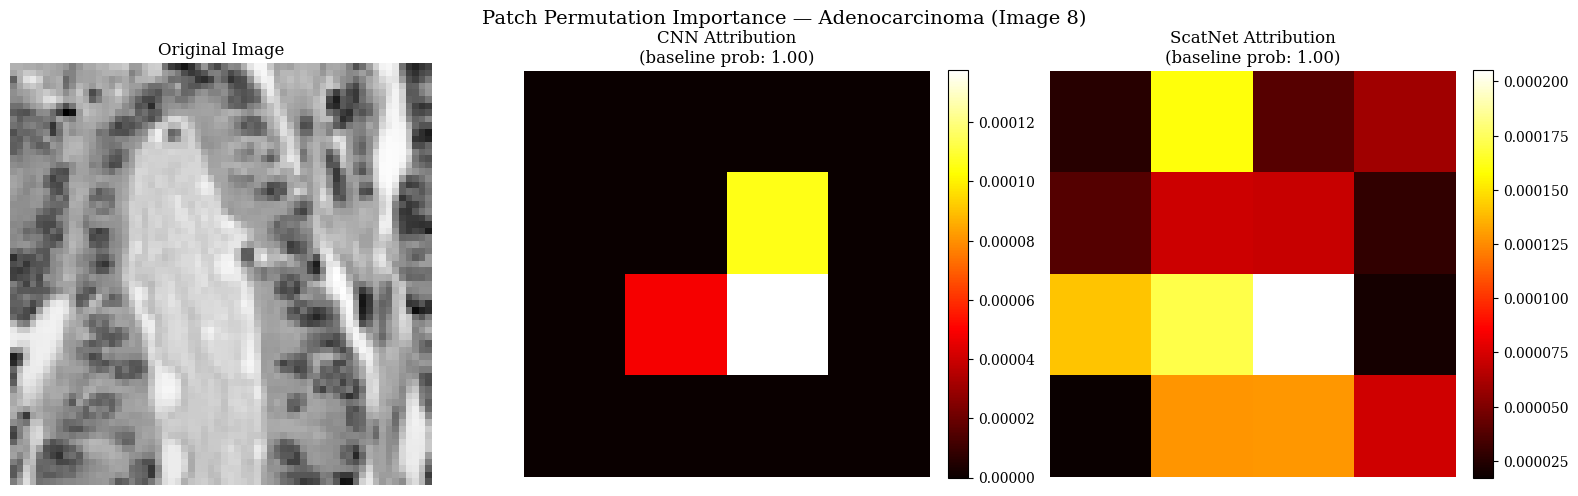

  Saved: xai_results/patch_permutation_adenocarcinoma_08.png
  Image 9/10...


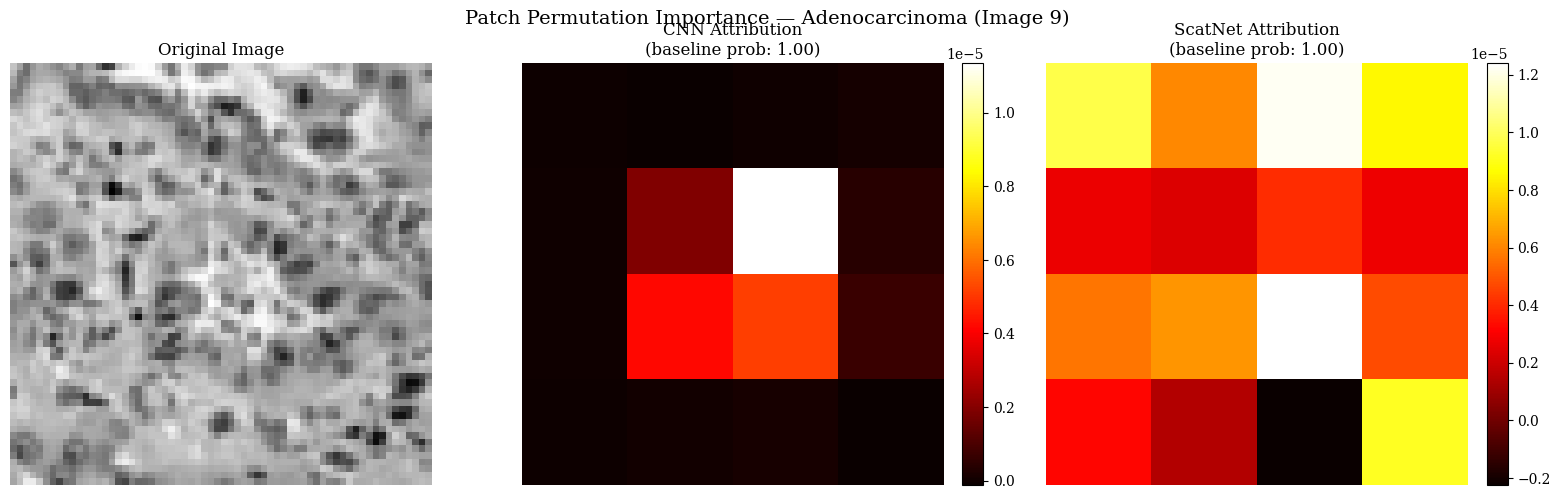

  Saved: xai_results/patch_permutation_adenocarcinoma_09.png
  Image 10/10...


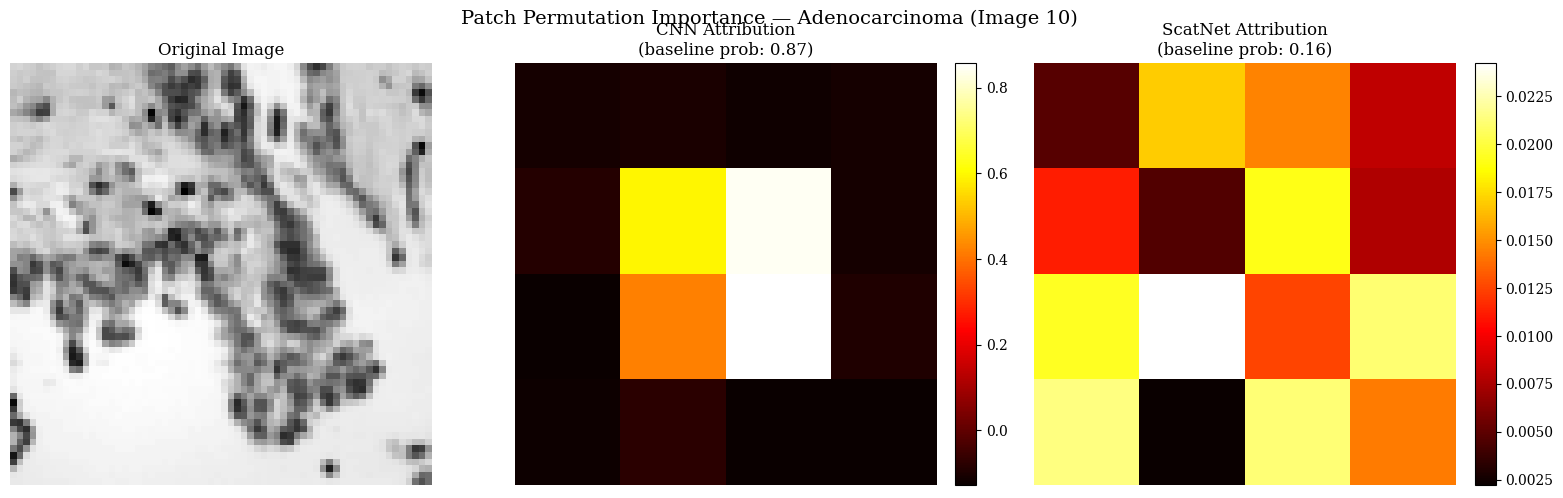

  Saved: xai_results/patch_permutation_adenocarcinoma_10.png

Done! Saved 20 heatmap figures to xai_results/


In [42]:
# ============================================================
# XAI — PART 1: PATCH PERMUTATION HEATMAPS (CNN vs ScatNet)
# 10 images per class — Benign and Adenocarcinoma
# Each figure: Original | CNN heatmap | ScatNet heatmap
# ============================================================
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

os.makedirs("xai_results", exist_ok=True)

def patch_permutation_heatmap(model, image_tensor, target_class, patch_size=16, n_repeats=5):
    model.eval()
    image = image_tensor.clone()
    if image.dim() == 3:
        image = image.unsqueeze(0)
    image = image.to(device)
    target_class = int(target_class)

    with torch.no_grad():
        orig_prob = torch.softmax(model(image), dim=1)[0, target_class].item()

    _, _, H, W = image.shape
    heatmap = np.zeros((H, W))

    for h in range(0, H, patch_size):
        for w in range(0, W, patch_size):
            drops = []
            for _ in range(n_repeats):
                corrupted = image.clone()
                patch = corrupted[:, :, h:h+patch_size, w:w+patch_size]
                flat = patch.reshape(-1)
                flat = flat[torch.randperm(flat.size(0))]
                corrupted[:, :, h:h+patch_size, w:w+patch_size] = flat.reshape(patch.shape)
                with torch.no_grad():
                    new_prob = torch.softmax(model(corrupted), dim=1)[0, target_class].item()
                drops.append(orig_prob - new_prob)
            heatmap[h:h+patch_size, w:w+patch_size] = np.mean(drops)

    return heatmap, orig_prob

# --- Collect 10 images per class from the full test set ---
n_per_class = 10
class_images = {0: [], 1: []}  # 0=Benign, 1=Adenocarcinoma
class_names  = {0: "Benign", 1: "Adenocarcinoma"}

for imgs, lbls in test_loader:
    for img, lbl in zip(imgs, lbls):
        c = lbl.item()
        if len(class_images[c]) < n_per_class:
            class_images[c].append(img)
    if all(len(v) >= n_per_class for v in class_images.values()):
        break

# --- Generate and save heatmaps ---
for class_idx, class_name in class_names.items():
    print(f"\nProcessing {n_per_class} images for class: {class_name}")

    for img_num, img_tensor in enumerate(class_images[class_idx]):
        test_image = img_tensor.unsqueeze(0).to(device)

        print(f"  Image {img_num+1}/{n_per_class}...")
        heatmap_cnn,  prob_cnn  = patch_permutation_heatmap(best_model_cnn, test_image, class_idx)
        heatmap_scat, prob_scat = patch_permutation_heatmap(full_scatnet,   test_image, class_idx)

        fig, axs = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(
            f"Patch Permutation Importance — {class_name} (Image {img_num+1})",
            fontsize=14
        )

        img_np = img_tensor.squeeze().cpu().numpy()
        axs[0].imshow(img_np, cmap="gray")
        axs[0].set_title("Original Image", fontsize=12)
        axs[0].axis("off")

        im1 = axs[1].imshow(heatmap_cnn, cmap="hot")
        axs[1].set_title(f"CNN Attribution\n(baseline prob: {prob_cnn:.2f})", fontsize=12)
        axs[1].axis("off")
        plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

        im2 = axs[2].imshow(heatmap_scat, cmap="hot")
        axs[2].set_title(f"ScatNet Attribution\n(baseline prob: {prob_scat:.2f})", fontsize=12)
        axs[2].axis("off")
        plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

        plt.tight_layout()
        fname = f"xai_results/patch_permutation_{class_name.lower()}_{img_num+1:02d}.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  Saved: {fname}")

print("\nDone! Saved 20 heatmap figures to xai_results/")

Class Benign: attribution computed on 1000 samples.
Class Adenocarcinoma: attribution computed on 1000 samples.


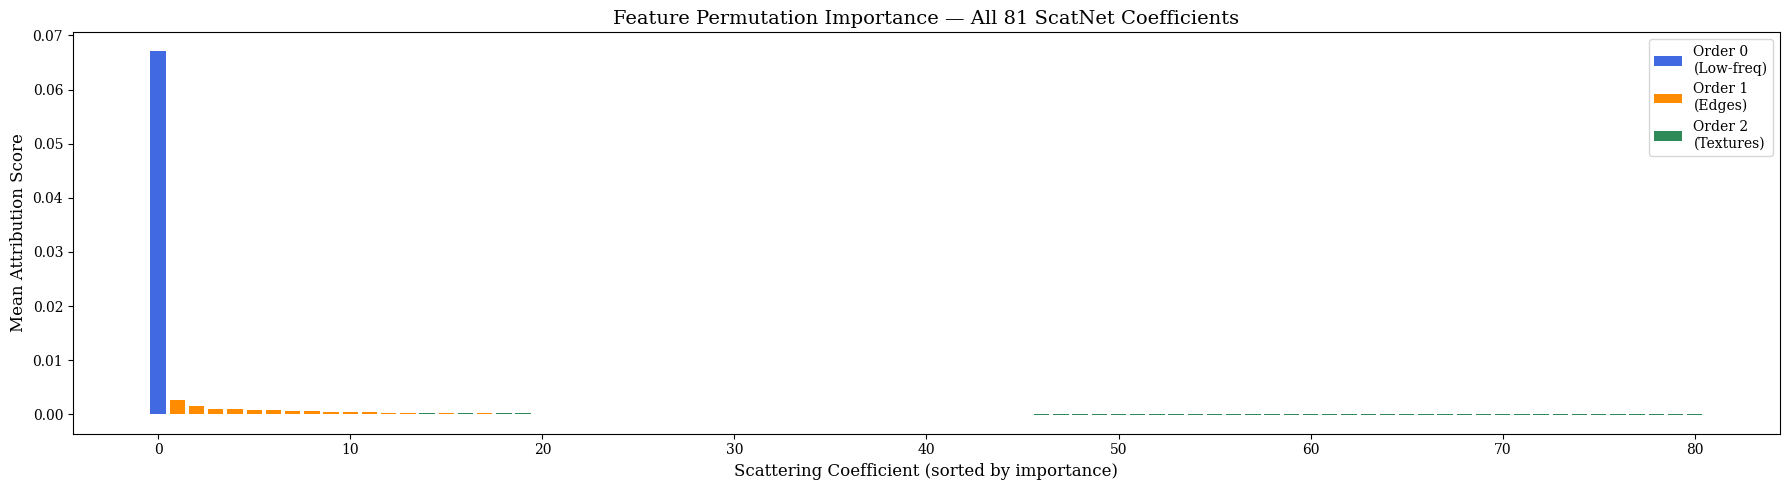

Saved: xai_results/feature_importance_all.png


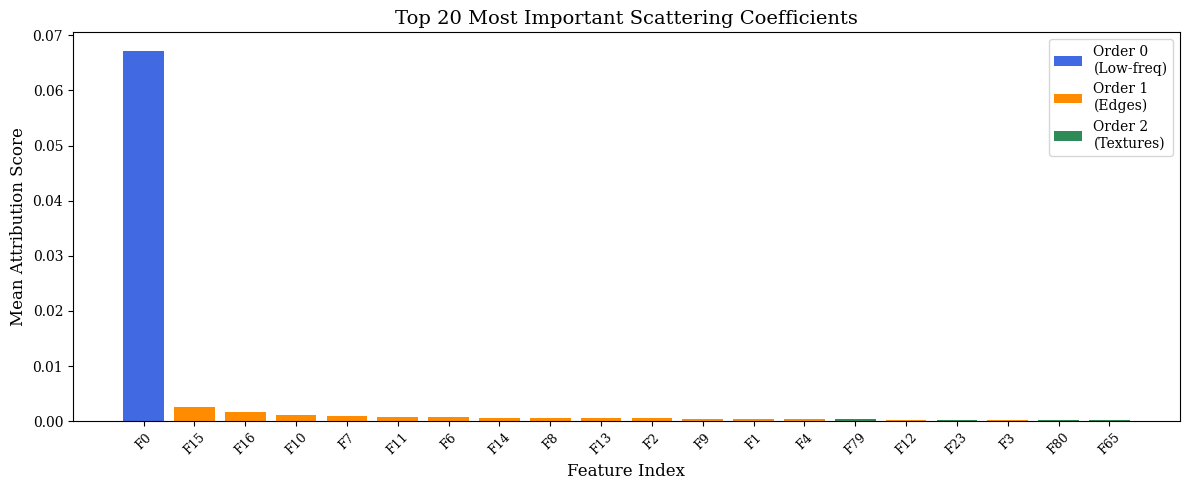

Saved: xai_results/feature_importance_top20.png


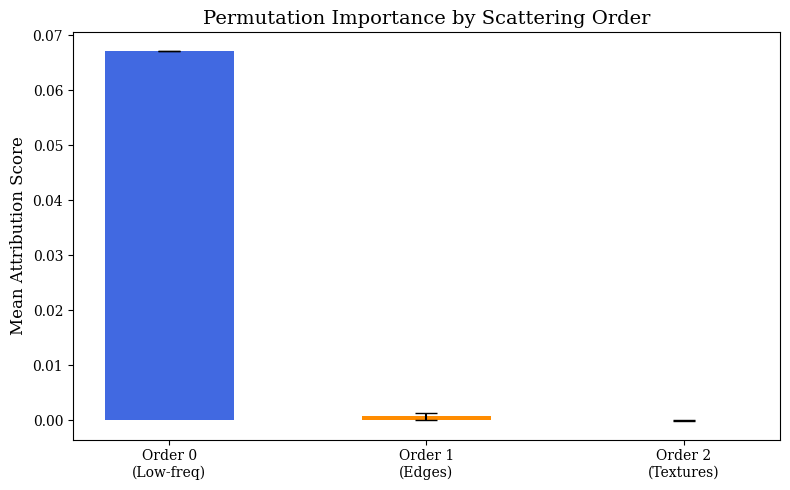

Saved: xai_results/feature_importance_by_order.png


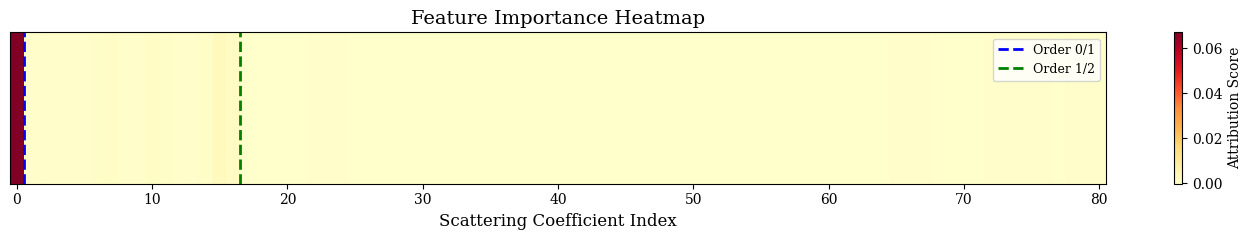

Saved: xai_results/feature_importance_heatmap.png


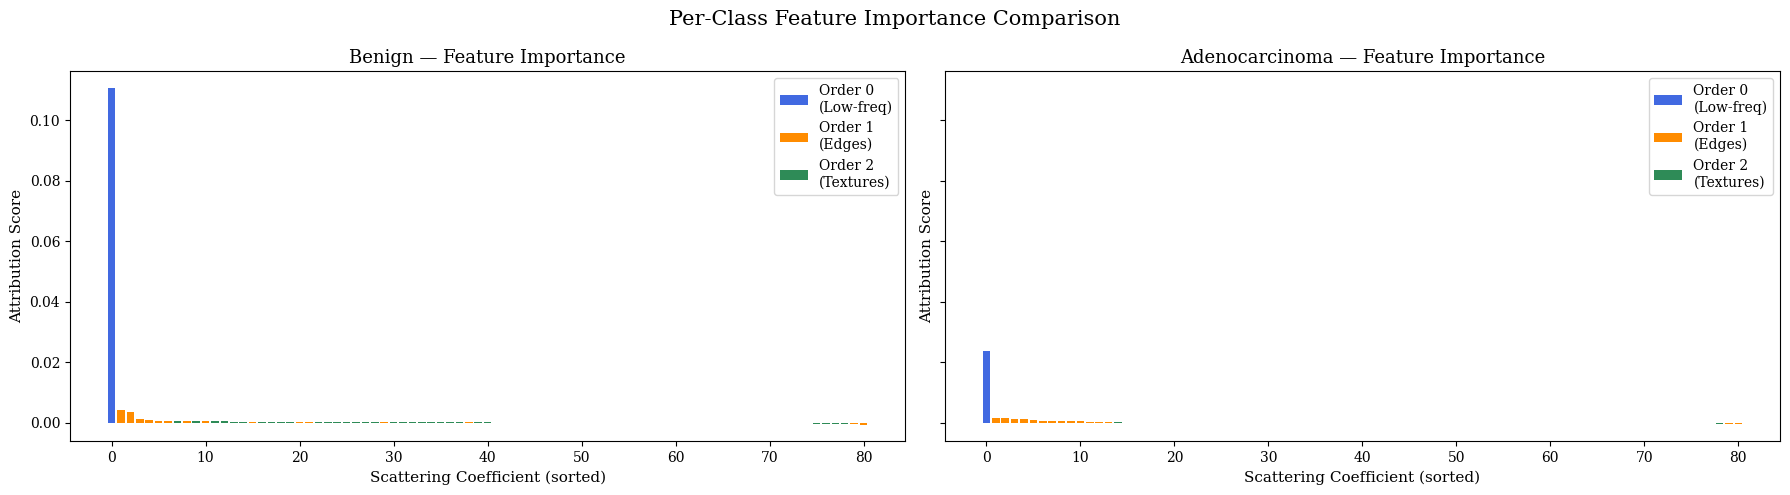

Saved: xai_results/feature_importance_per_class.png

All results saved to xai_results/
Files: patch_permutation_benign.png, patch_permutation_adenocarcinoma.png,
       feature_importance_all.png, feature_importance_top20.png,
       feature_importance_by_order.png, feature_importance_heatmap.png,
       feature_importance_per_class.png, importance_summary.txt


In [40]:
# ============================================================
# XAI — PART 2: SCATNET FEATURE PERMUTATION (Captum)
# Visualises WHICH of the 81 scattering coefficients matter.
# ============================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from captum.attr import FeaturePermutation
import os

os.makedirs("xai_results", exist_ok=True)

# Scattering order groups for J=2, L=8 → 81 coefficients
# Order 0: 1 coeff, Order 1: J*L=16, Order 2: remaining 64
order_groups = {
    "Order 0\n(Low-freq)":  list(range(0, 1)),
    "Order 1\n(Edges)":     list(range(1, 17)),
    "Order 2\n(Textures)":  list(range(17, 81)),
}
color_map = {
    "Order 0\n(Low-freq)":  "royalblue",
    "Order 1\n(Edges)":     "darkorange",
    "Order 2\n(Textures)":  "seagreen",
}

# --- Extract scattering features from test set ---
scattering_xai = Scattering2D(J=2, shape=(64, 64), L=8).to(device)

X_feats, y_true = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        Sx = scattering_xai(imgs).squeeze(1)        # [B, 81, 16, 16]
        feats = Sx.mean(dim=(-1, -2))               # [B, 81]
        X_feats.append(feats.cpu())
        y_true.extend(lbls.tolist())

X_feats = torch.cat(X_feats, dim=0)   # [N, 81]
y_true  = torch.tensor(y_true)        # [N]

# --- Captum FeaturePermutation per class target ---
fp = FeaturePermutation(best_model_scat)
importances_per_class = {}

for target_cls in [0, 1]:
    cls_name = "Benign" if target_cls == 0 else "Adenocarcinoma"
    mask = (y_true == target_cls)
    X_cls = X_feats[mask].to(device)

    if X_cls.size(0) == 0:
        print(f"No samples for class {target_cls}, skipping.")
        continue

    best_model_scat.eval()
    attr = fp.attribute(X_cls, target=target_cls)   # [N_cls, 81]
    importance = attr.mean(dim=0).detach().cpu().numpy()  # [81]
    importances_per_class[cls_name] = importance
    print(f"Class {cls_name}: attribution computed on {X_cls.size(0)} samples.")

# Use mean across both classes as global importance
global_importance = np.mean(list(importances_per_class.values()), axis=0)

# --- Assign colors by scattering order ---
feat_colors = []
for i in range(81):
    for order_name, indices in order_groups.items():
        if i in indices:
            feat_colors.append(color_map[order_name])
            break

sorted_idx = np.argsort(global_importance)[::-1]
sorted_colors = [feat_colors[i] for i in sorted_idx]

legend_elements = [Patch(facecolor=c, label=l) for l, c in color_map.items()]

# ---- Plot 1: All 81 features ----
plt.figure(figsize=(18, 5))
plt.bar(range(81), global_importance[sorted_idx], color=sorted_colors)
plt.xlabel("Scattering Coefficient (sorted by importance)", fontsize=12)
plt.ylabel("Mean Attribution Score", fontsize=12)
plt.title("Feature Permutation Importance — All 81 ScatNet Coefficients", fontsize=14)
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig("xai_results/feature_importance_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xai_results/feature_importance_all.png")

# ---- Plot 2: Top 20 ----
top20 = sorted_idx[:20]
plt.figure(figsize=(12, 5))
plt.bar(range(20), global_importance[top20], color=[feat_colors[i] for i in top20])
plt.xticks(range(20), [f"F{i}" for i in top20], rotation=45, fontsize=9)
plt.xlabel("Feature Index", fontsize=12)
plt.ylabel("Mean Attribution Score", fontsize=12)
plt.title("Top 20 Most Important Scattering Coefficients", fontsize=14)
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig("xai_results/feature_importance_top20.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xai_results/feature_importance_top20.png")

# ---- Plot 3: Grouped by scattering order ----
group_means = {k: global_importance[v].mean() for k, v in order_groups.items()}
group_stds  = {k: global_importance[v].std()  for k, v in order_groups.items()}

plt.figure(figsize=(8, 5))
plt.bar(group_means.keys(), group_means.values(),
        yerr=group_stds.values(),
        color=[color_map[k] for k in group_means],
        capsize=8, width=0.5)
plt.ylabel("Mean Attribution Score", fontsize=12)
plt.title("Permutation Importance by Scattering Order", fontsize=14)
plt.tight_layout()
plt.savefig("xai_results/feature_importance_by_order.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xai_results/feature_importance_by_order.png")

# ---- Plot 4: Heatmap ----
fig, ax = plt.subplots(figsize=(14, 2.5))
im = ax.imshow(global_importance.reshape(1, -1), aspect="auto", cmap="YlOrRd")
ax.set_yticks([])
ax.set_xlabel("Scattering Coefficient Index", fontsize=12)
ax.set_title("Feature Importance Heatmap", fontsize=14)
plt.colorbar(im, ax=ax, label="Attribution Score")
ax.axvline(x=0.5,  color="blue",  linewidth=2, linestyle="--", label="Order 0/1")
ax.axvline(x=16.5, color="green", linewidth=2, linestyle="--", label="Order 1/2")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("xai_results/feature_importance_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xai_results/feature_importance_heatmap.png")

# ---- Plot 5: Per-class comparison ----
if len(importances_per_class) == 2:
    fig, axs = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
    for ax, (cls_name, imp) in zip(axs, importances_per_class.items()):
        s_idx = np.argsort(imp)[::-1]
        ax.bar(range(81), imp[s_idx], color=[feat_colors[i] for i in s_idx])
        ax.set_title(f"{cls_name} — Feature Importance", fontsize=13)
        ax.set_xlabel("Scattering Coefficient (sorted)", fontsize=11)
        ax.set_ylabel("Attribution Score", fontsize=11)
        ax.legend(handles=legend_elements)
    plt.suptitle("Per-Class Feature Importance Comparison", fontsize=15)
    plt.tight_layout()
    plt.savefig("xai_results/feature_importance_per_class.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: xai_results/feature_importance_per_class.png")

# ---- Summary text ----
with open("xai_results/importance_summary.txt", "w") as f:
    f.write("=== Global Feature Importance Summary ===\n\n")
    f.write("Top 10 most important scattering coefficients:\n")
    for rank, idx in enumerate(sorted_idx[:10]):
        order = next(k for k, v in order_groups.items() if idx in v)
        f.write(f"  Rank {rank+1}: Feature {idx:3d} ({order.replace(chr(10), ' ')}) — score: {global_importance[idx]:.4f}\n")
    f.write("\nGrouped by scattering order:\n")
    for name, mean_val in group_means.items():
        f.write(f"  {name.replace(chr(10), ' ')}: {mean_val:.4f} ± {group_stds[name]:.4f}\n")
    f.write("\nPer-class breakdown:\n")
    for cls_name, imp in importances_per_class.items():
        top5 = np.argsort(imp)[::-1][:5]
        f.write(f"  {cls_name} top-5: {list(top5)}\n")

print("\nAll results saved to xai_results/")
print("Files: patch_permutation_benign.png, patch_permutation_adenocarcinoma.png,")
print("       feature_importance_all.png, feature_importance_top20.png,")
print("       feature_importance_by_order.png, feature_importance_heatmap.png,")
print("       feature_importance_per_class.png, importance_summary.txt")
